# **Tutorial 2** $\cdot$ Structure Attribution Methods

> **Abstract.** This tutorial introduces *structure-attribution methods* for explaining graph neural network (GNN) predictions in molecular property prediction. Unlike feature-attribution methods that assign importance to abstract descriptors, structure-attribution methods highlight the specific atoms and bonds within a molecule that drive the model's predictions &mdash; providing direct insight into the structure-property relationships (SPR) a model has learned. We demonstrate three complementary approaches: (1) **GNNExplainer**, a perturbation-based method that optimizes a soft mask to identify important substructures; (2) **ZORRO**, a greedy method that extracts a sparse, *hard* set of atoms that is by itself sufficient to reproduce the prediction; and (3) **MEGAN**, a self-explaining graph attention network that produces multi-channel explanations as an intrinsic part of its forward pass. Using the AqSolDB aqueous-solubility dataset as a case study, we train GNN models to predict water solubility (logS), generate explanations with each method, and compare their outputs side-by-side. The tutorial highlights how the methods can agree on chemically meaningful substructures (such as polar hydroxyl groups or extended hydrophobic ring systems) while having their own advantages and disadvantages.

**💾 Dataset.** This tutorial uses the *AqSolDB* dataset, a curated regression benchmark of aqueous solubility for roughly ten thousand diverse organic molecules. Each molecule is represented by a SMILES string and labeled with its experimentally measured log-solubility value (logS). Because solubility is strongly governed by molecular structure &mdash; polar groups tend to increase it while large hydrophobic moieties decrease it &mdash; it is well-suited for demonstrating structure-attribution methods that highlight the substructures responsible for a prediction.

**📦 Packages.** Packages used in this notebook include:
- [RDKit](https://www.rdkit.org/docs/index.html) Cheminformatics framework for processing of SMILES strings and the calculation of molecular descriptors and fingerprints.
- [Pandas](https://pandas.pydata.org/docs/index.html) for data representation and processing.
- [Pytorch](https://docs.pytorch.org/docs/stable/index.html) and [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) for the training of simple neural network models based on the molecular representations.
- [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) framework for the construction, training and explanation of graph neural network (GNN)-based property prediction models.
- [NetworkX](https://networkx.org/) for the representation and visualization of graph structured data.
- [zorrito](https://github.com/the16thpythonist/zorrito) for ZORRO, valid/sparse/stable hard-mask explanations for PyTorch Geometric GNNs.
- [graph_attention_student](https://github.com/aimat-lab/graph_attention_student) for MEGAN, a self-explaining graph attention network with built-in multi-channel explanations.

In [1]:
import os
import random

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import pytorch_lightning as pl
import torch.nn as nn
import torch.nn.functional as F
import rdkit.Chem as Chem
from rdkit import RDLogger
from rich.pretty import pprint
from torch.utils.data import TensorDataset
from torch.utils.data import Subset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torchmetrics import R2Score, MeanAbsoluteError

from xai_chem_review import load_dataset_aqsoldb

# Set the matplotlib style
plt.style.use('default')
# Disable all RDKit warnings
RDLogger.DisableLog('rdApp.*')

In [2]:
data_frame: pd.DataFrame = load_dataset_aqsoldb()

print(f'Using dataset with {data_frame.shape[0]} rows')
print('Solubility (logS) statistics:')
print(data_frame['solubility'].describe())
data_frame.head()

Using dataset with 11024 rows
Solubility (logS) statistics:
count    11024.000000
mean        -2.880460
std          2.343010
min        -13.171900
25%         -4.286934
50%         -2.600300
75%         -1.228457
max          2.137682
Name: solubility, dtype: float64


,index,ID,smiles,InChIKey,solubility,split
0,0,A-10,Cc1cccc(C=C)c1,JZHGRUMIRATHIU-UHFFFAOYSA-N,-3.123150,1
1,1,A-100,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,ODJUOZPKKHIEOZ-UHFFFAOYSA-N,-4.952869,1
2,2,A-1000,O=C1CCCCCCCCCOCCCCCO1,MKEIDVFLAWJKMY-UHFFFAOYSA-N,-3.883849,1
3,3,A-1002,CCCCCCCCCCC(C)CCCCCCCC,FFVPRSKCTDQLBP-UHFFFAOYSA-N,-6.451105,1
4,4,A-1003,NC(=O)N=NC(N)=O,XOZUGNYVDXMRKW-UHFFFAOYSA-N,-3.546243,1


## **2.1** $\cdot$ 💡 Structure-Attributional Explanations

Unlike the previously showcased methods, structure-attribution methods operate on the level of *graph structure*. Rather than attributing importance to abstract features (e.g. molecular weight), importance scores are computed for the individual elements of the molecular graph &mdash; namely its nodes (atoms) and edges (bonds). By highlighting important nodes and edges, these methods represent a view on the structure-property relationships (SPR) underlying the model's predictive decisions.

One primary difference between the two types of attributional explanations is the choice of the underlying model. Feature-attibutional explanations can be more easily obtained from models which directly use these features as the basis of their predictions. As shown in the previous tutorial, simple predictive models based on molecular descriptors can be used to generate such explanations. On the contrary, structure-attributional explanations can be more easily obtained through the use of *graph neural networks (GNNs)*. Instead of a fixed-size vector input, these GNN models operate directly on the abstract graph representation of the molecule. Due to their different operating principles, most explainability methods wont be directly applicable to graph neural networks. Although many methods (including SHAP and LIME) have been adpated to work with graph neural networks as well, there also exist a plethora of approaches designed to generate explanations specifically for GNNs.

## **2.2** $\cdot$ 📚 *Graph Neural Network Explainer* (`GNNExplainer`)

The first example method from the literature was proposed by [Ying *et al.*](https://arxiv.org/abs/1903.03894) in 2019 and is called *GNNExplainer*. The method is based on the idea of using input perturbations to extract those parts of the graph structure which are the most important for a given model prediction. 

For a given graph structure and it's original prediction, each explanation is created by optimizing the weights of a mask over the given graph. The components of the mask correspond to the individual elements of the graph (nodes and edges) and their 0 to 1 values determine if the model is able to "see" the element (=1) or not (=0) during it's prediction. In the process of multiple predictions, the components of the mask are then adjusted such that a large part of the graph is "hidden" from the model while changing the model's *prediction* as little as possible. Therefore, the final optimized mask shows the subset of nodes and edges most important to the model to form it's final decision.

**Implementation.** To use GNNExplainer, we'll first have to train a graph neural network, which will be done with the popular [Pytorch Geometric (PyG)](https://pytorch-geometric.readthedocs.io/en/latest/) framework. Aside from various GNN architectures themselves, PyG has since also implemented the ``torch_geometric.explain`` package which offers existing implementations of some common graph explanation methods - including GNNExplainer.

### Molecular Graph Processing

As previously introduced, we want to use a graph neural network based on the popular [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) library for our main property prediction model. Do do molecular property prediction, such a GNN model needs to receive the various molecules in a *graph representation*. As a very first step, before implementing the model itself, we therefore have to construct a data-processing pipeline that can be used to convert the molecules into these graph representaitons.

**Graph Representation.** On a technical level, a PyG GNN model will need to receive the graphs in the format of a `torch_geometric.data.Data` object. A first option would be to write some function `data_from_smiles` which converts a given SMILES representation of a molecule into such a `Data` object. However, as in the previous notebook, it also makes sense to invest more thought about how the graph-based explanations will be visualized later on. For the processing and handling of graphs there already exists very useful python package called `networkx`. This package also has lots of *built-in* functionality for the manipulation and visualization of these graphs which will be useful for the explanations later on. Consequently, a good option would be to use the `networkx.Graph` object as an *intermediate representation* - based on which the visualization can be handled more easily later on. Using this intermediate representation we'll therefore have to create two seperate functions `graph_from_smiles` and `data_from_graph`.

**Feature Extraction.** When converting a molecule into a machine-readable graph representation, another question that comes up is that of feature extraction. However, unlike with molecular descriptors, the feature extraction in this case will have to be done on the level of individual atoms and bonds &mdash; rather than on the level of the entire molecule. When a GNN model is creating a prediction based on the graph structure of a molecule, each node and edge of this graph need to contain some form of vectorized information about whether a node represents a carbon or an oxygen atom, for example. We therefore need to implement two additional functions `encode_atom(atom: Chem.Atom) -> np.ndarray` and `encode_bond(bond:Chem.Bond) -> np.ndarray` which can be used to calculate these numeric feature vectors corresponding to the individual nodes and atoms.

In [3]:
def encode_atom(atom: Chem.Atom,
                supported_atoms: list[str] = ['C', 'N', 'O', 'S', 'P', 'Cl', 'Br', 'F'],
                ) -> np.ndarray:
    """
    Encodes a given RDKit `atom` object into a fixed-size vector representation of its properties - including 
    a one-hot encoding of the atom type, as well as information about the atom's valence and charge.
    
    :param atom: The Chem.Atom object to be converted.
    :param supported_atoms: A list of atom symbols that are supported for the one-hot encoding. 
        If the given atom's symbol is not in this list, it will be marked as unknown which is 
        an additional one-hot encoded quantity in the output vector.
        
    :return: A numpy array of shape (n_feature, ) containing the encoded atom properties.
    """
    
    # The first part of the encoded vector is a one-hot representation of the atom type. Note that only 
    # the subset of atoms defined in the `supported_atoms` list will supported for explicit encoding. 
    # If the atom's symbol is not in this list, it will be marked as unknown, which is another additional
    # one-hot encoded quantity in the output vector.
    atom_one_hot = np.zeros(len(supported_atoms), dtype = np.float32)
    if atom.GetSymbol() in supported_atoms:
        atom_one_hot[supported_atoms.index(atom.GetSymbol())] = 1.0
    
    atom_unknown = float(atom.GetSymbol() not in supported_atoms)
    
    # Additionally, we want to provide information about the atom valence and charge, as this information 
    # will also implicitly communicate the number of implicitly attached hydrogens to the atom.
    atom_valence = atom.GetTotalValence()
    atom_valence_implicit = atom.GetImplicitValence()
    atom_charge = atom.GetFormalCharge()
    
    # Finally, we package the information into a single numeric vector
    return np.array([
        *atom_one_hot,
        atom_unknown,
        atom_valence,
        atom_valence_implicit,
        atom_charge,
    ], dtype = np.float32)


def encode_bond(bond: Chem.Bond,
                supported_bond_types: list[int] = [
                    Chem.BondType.SINGLE, 
                    Chem.BondType.DOUBLE, 
                    Chem.BondType.TRIPLE, 
                ],
                ) -> np.ndarray:
    """
    Encodes a given RDKit `bond` object into a fixed-size vector representation of its properties - including
    a one-hot encoding of the bond type, as well as information about the bond's stereo configuration and whether it is aromatic.
    
    :param bond: The Chem.Bond object to be converted.
    :param supported_bond_types: A list of bond types that are supported for the one-hot encoding. 
    
    :return: A numpy array of shape (n_feature, ) containing the encoded bond properties.
    """
    # The first part of the encoded vector is a one-hot representation of the bond type.
    # Note that only the subset of bond types defined in the `supported_bond_types` list will supported for explicit encoding. 
    # If the bond type is not in this list, it will be marked as unknown, which is another additional
    # one-hot encoded quantity in the output vector.
    bond_type_one_hot = np.zeros(len(supported_bond_types), dtype = np.float32)
    if bond.GetBondType() in supported_bond_types:
        bond_type_one_hot[supported_bond_types.index(bond.GetBondType())] = 1.0
        
    bond_unknown = float(bond.GetBondType() not in supported_bond_types)
    
    # Additionally, we want to provide information about the bond's stereo configuration and whether it is aromatic.
    bond_stereo = bond.GetStereo()
    bond_aromatic = float(bond.GetIsAromatic())
    
    return np.array([
        *bond_type_one_hot,
        bond_unknown,
        bond_stereo,
        bond_aromatic,
    ], dtype = np.float32)


**Example Node and Edge Encoding.** After defining these two functions we can look at an example of how they work. For this purpose we will create two artificial objects &mdash; one <code>Atom</code> and one <code>Bond</code> object &mdash; and then apply the feature extraction functions on those to see what the results look like.

In [4]:
# We use a single carbon atom as the example.
example_atom: Chem.Atom = Chem.Atom('C')
atom_features: np.ndarray = encode_atom(example_atom)

print('Atom (C)')
print('========')
print(f'{type(example_atom).__name__} object: {example_atom}')
print(f'Atom Features: {atom_features}')
features = ['is carbon?', 'is nitrogen?', 'is oxygen?', 'is sulfur?',
            'is phosphor?', 'is chlorine?', 'is bromine?', 'is flourine?',
            'is other?']
for feature, value in zip(features, atom_features):
    print(f'{feature.ljust(20)} - {bool(value)}') 
print()

# For the bond, we look at a simple bond between a carbon and and an oxygen atom.
# Constructing a standalone bond is a little bit more complicated than an atom. To 
# get the bond we first have to initialize an "empty" molecule to which we than add 
# the bond.
mol_rw = Chem.RWMol()
c_idx = mol_rw.AddAtom(Chem.Atom('C'))
n_idx = mol_rw.AddAtom(Chem.Atom('N'))
mol_rw.AddBond(c_idx, n_idx, Chem.BondType.SINGLE)

example_bond: Chem.Bond = mol_rw.GetBondWithIdx(0)
bond_features: np.ndarray = encode_bond(example_bond)

print('Bond (C-O)')
print('==========')
print(f'{type(example_bond).__name__} object: {example_bond}')
print(f'Bond Features: {bond_features}')
features = ['is single bond?', 'is double bond?', 'is triple?', 'is other?',
            'is stereo?', 'is aromatic?']
for feature, value in zip(features, atom_features):
    print(f'{feature.ljust(20)} - {bool(value)}') 
print()

Atom (C)
Atom object: <rdkit.Chem.rdchem.Atom object at 0x7c563dbe0090>
Atom Features: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
is carbon?           - True
is nitrogen?         - False
is oxygen?           - False
is sulfur?           - False
is phosphor?         - False
is chlorine?         - False
is bromine?          - False
is flourine?         - False
is other?            - False

Bond (C-O)
Bond object: <rdkit.Chem.rdchem.Bond object at 0x7c563dbc4820>
Bond Features: [1. 0. 0. 0. 0. 0.]
is single bond?      - True
is double bond?      - False
is triple?           - False
is other?            - False
is stereo?           - False
is aromatic?         - False



**🔍 Atom and Bond Features.** As we can see, each atom and each bond can be mapped into a numeric vector which describes its most important properties. How exactly this vector is structured is up to the developer and can be considered as part of a hyperparameter optimization.

<details style="border: 1.5px #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 Different Feature Representations</summary>

Aside from <em>which</em> features to include, another question may be <em>how</em> to best represent them.

<strong>Categorical vs. ordinal.</strong> Consider the atom type. The most compact option would be to encode it as a single number &mdash; the atomic number $Z$, for instance, so that carbon becomes <code>6</code> and oxygen <code>8</code>. Such a scalar is not meaningless: atomic weight broadly scales with $Z$, and several periodic-table trends such as electronegativity loosely track it, so the ordering does carry <em>some</em> genuine chemical signal. The catch is that it forces a <em>single, rigid ordering</em> onto a property that really varies along several axes at once, and chemically important distinctions between elements are not always faithfully captured by where they happen to fall on the number line. From a machine-learning perspective there is a further consideration: compressing something as fundamental as element identity into one attribute among many others may "water it down", making it harder for the model to give that information the weight it often deserves. A <strong>one-hot encoding</strong> takes the opposite stance &mdash; it grants every supported type its own dedicated axis, so that the types are mutually equidistant and element identity is exposed as a prominent, easily separable signal rather than a single shared dimension. The cost is dimensionality: one extra feature per supported element (plus a catch-all bucket for unknown types).

<strong>Genuinely continuous quantities.</strong> Not every property is categorical. Attributes such as valence, formal charge, atomic weight or the number of implicitly attached hydrogens are naturally <em>ordered</em> and are sensibly represented as plain scalar values, where a difference of one really does mean "one more". A subtler question is that of <em>redundancy</em>. Many such quantities are not independent &mdash; the number of implicit hydrogens, for example, follows directly from an atom's element, its bonds and its charge. In principle a sufficiently expressive model could re-derive these relationships on its own, which raises the question of whether providing them explicitly is worthwhile at all.

<strong>Why include them anyway.</strong> In practice, supplying redundant-but-explicit features is often beneficial: it injects established chemical knowledge as an <em>inductive bias</em>, sparing the model from having to rediscover textbook chemistry from limited data and frequently improving sample efficiency and generalization &mdash; at the price of a larger, more correlated input vector. There is consequently no single "correct" feature representation. The choice between compact scalars, sparse one-hot vectors and explicit redundant descriptors is itself a design decision that trades off expressiveness, inductive bias, dimensionality and interpretability, and the best mix tends to depend on the dataset size, the model capacity and the task at hand &mdash; which is why featurization is best regarded as part of the hyperparameter search.

</details>

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 2.1** $\cdot$ As you can see, the individual atoms of a molecule are represented by a relatively small number of features. Only a handful of the most frequent atom types are explicitly covered (C, N, O, ...). Atoms with any other type than the ones explicitly covered would all fall under the umbrella class of "other" types. Consequently, all of these atoms would <em>"look the same"</em> to the model. The choice of which types, or more generally which features, to include also heavily depends on the target domain. Applications in small molecule organic chemistry will most likely require different features than something like catalyst activity prediction.

As an exercise, try to extend the atom feature vector to also include <em>iodine</em> and <em>magnesium</em> as explicitly handled atom types. Also think about which subsequent code you'll have to adjust as a consequence of such as change.
</div>

**Graph Processing and Visualization.** The following code introduces the <code>graph_from_smiles</code> function which converts the SMILES string representation of a molecule into the <code>networkx.Graph</code> representation, while also computing the node and edge features (as previously introduced) and storing them alongside each node and edge of the resulting graph. In addition to this conversion, we also want to define the <code>draw_graph</code> function which uses existing networkx functionality to create a visual representation of this graph structure. We'll also be using this graph visualization as the basis of the subsequent visualizations of the explanation methods, which will designate different parts of this graph structure as more (or less) important.

In [5]:

def graph_from_smiles(
    smiles: str,
    atom_encoder: callable = encode_atom,
    bond_encoder: callable = encode_bond,
) -> nx.Graph:
    """
    Given a `smiles` string, this function constructs a graph representation corresponding to that molecule and returns 
    it in the format of a `networkx.Graph` object.
    
    :param smiles: The SMILES string of the molecule to be converted into a graph.
    :param atom_encoder: A callable function that encodes an RDKit `atom` object into a fixed size numpy array which 
        will be attached to the node representation of the molecular graph.
    :param bond_encoder: A callable function that encodes an RDKit `bond` object into a fixed size numpy array which
        will be attached to the edge representation of the molecular graph.
        
    :return: A `networkx.Graph` object representing the molecule, where nodes correspond to atoms and edges correspond to bonds.
    """
    
    ## --- Constructing MOL object ---
    # We first have to use RDKit to convert the SMILES string into a MOL object - consisting of the individual atoms and bonds 
    # that make up the molecule.
    
    mol: Chem.Mol = Chem.MolFromSmiles(smiles)

    # RDKit returns None for SMILES strings it cannot parse (some AqSolDB entries are
    # malformed salts/mixtures or use unsupported notation). Returning None here lets the
    # downstream filter drop these molecules instead of crashing.
    if mol is None:
        return None

    ## --- Constructing graph from MOL object ---
    # Afterwards, we can iterate over the individual elements (atoms, bonds) of this molecule object and construct a corresponding 
    # graph representation using networkx.
    # One important aspect in this process is how to represent the individual atoms and bonds in the graph.

    g: nx.Graph = nx.Graph() # Empty graph
    
    # At first we iterate over the atoms in the molecule and add each atom as a node.
    for atom in mol.GetAtoms():
        
        # `atom_encoder` is a callable function that encodes the atom into a fixed-size vector representation.
        node_attributes: np.ndarray = atom_encoder(atom)
        
        g.add_node(
            atom.GetIdx(),
            # Associate each node with a uniquely indentifiable index.
            node_index=atom.GetIdx(),
            # Store the string (!) representation of the atom symbol as metadata. This will later on 
            # be useful for the visualization.
            node_atom=atom.GetSymbol(), 
            # Additionally attach the numeric node attributes, which will be used for the model 
            # predictions.
            node_attributes=node_attributes
        )

    # After the nodes have been added, we can iterate over the bonds in the molecule and add each bond as an edge.
    for bond in mol.GetBonds():
        
        # `bond_encoder` is a callable function that encodes the bond into a fixed-size vector representation.
        edge_attributes: np.ndarray = bond_encoder(bond)
        
        g.add_edge(
            # Edges are defined based on the indices of the nodes that are involved.
            bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(),
            # Store the string (!) representation of the bond type as metadata. This will later on
            # be useful for the visualization.
            edge_type=bond.GetBondType(),
            # Additionally attach the numeric edge attributes, which will be used for the model 
            # predictions.
            edge_attributes=edge_attributes,
        )

    # Return the now populated graph object.
    return g


## --- Graph Visualization ---
# functionality to be able to *look* at and visually inspect the converted graph 
# structures.

def draw_graph(
    g: nx.Graph,
    ax: plt.Axes,
    atom_color_map: dict[str, str] = {
        'C': 'gray', 
        'O': 'red', 
        'N': 'blue', 
        'S': 'yellow', 
        'P': 'orange', 
        'Cl': 'green', 
        'Br': 'brown', 
        'F': 'purple'
    },
    edge_styles: dict[int, str] = {
        Chem.BondType.SINGLE: 'solid',
        Chem.BondType.DOUBLE: 'dashed',
        Chem.BondType.TRIPLE: 'dashdot',
    }
) -> dict:
    """
    Draws a molecular graph visualization on the given axes.
    
    :param g: The networkx graph to draw.
    :param ax: The matplotlib axes to draw on.
    :param atom_color_map: Mapping from atom symbols to colors.
    :param edge_styles: Mapping from bond types to line styles.
    :returns: Dictionary of node positions.
    """
    
    # networkx (nx) supports different layouting styles to display the graphs in the 2 
    # dimensional plane of the plot. One style is for example "circular" where all of the 
    # nodes are displayed equidistantly on a circle. While not exactly reproducing the 
    # look of known molecule visualizations, the existing "kamada kawai" style reproduces 
    # the best approximation of how molecules are usually depicted.
    # The layouting function generates a 2D array of (x, y) positions within the plot's 
    # coordinate system - one for each node within the graph. This information about the 
    # positions will have to be passed along to many of the subsequent visualization functions 
    # provided by networkx.
    pos: np.ndarray = nx.kamada_kawai_layout(g)

    for (u, v, data) in g.edges(data=True):
        
        # We'll visually represent the different edge types by drawing the 
        # corresponding edges of the graph in different styles - e.g. solid edges
        # for single bonds or dashed edges for double bonds etc.
        style = edge_styles.get(data['edge_type'], 'solid')
        
        # This function draws the actual lines onto the plot's canvas.
        # Note that we are purposefully drawing the edges before the nodes 
        # such that the nodes partially cover the edge lines instead of 
        # the other way around. 
        nx.draw_networkx_edges(
            g, pos,
            edgelist=[(u, v)],
            style=style,
            width=2,
            edge_color='gray',
            ax=ax  # Pass the axes explicitly
        )

    node_colors = [
        atom_color_map.get(g.nodes[node]['node_atom'], 'lightblue') 
        for node in g.nodes()
    ]
    
    # This function draws the actual circles - meant to represent the atoms - onto 
    # the plot using the colors which were determined by the node type (atomic species)
    nx.draw_networkx_nodes(
        g, pos,
        node_color=node_colors,
        node_size=700,
        ax=ax  # Pass the axes explicitly
    )
    
    # An additional function "draw_networkx_labels" is then used to write the letter 
    # to represent an atom type (C, N, O, ...) into the center of these circles.
    node_labels = {node: data['node_atom'] for node, data in g.nodes(data=True)}
    nx.draw_networkx_labels(
        g, 
        pos, 
        labels=node_labels, 
        font_size=12, 
        font_color='black', 
        ax=ax
    )
    
    return pos

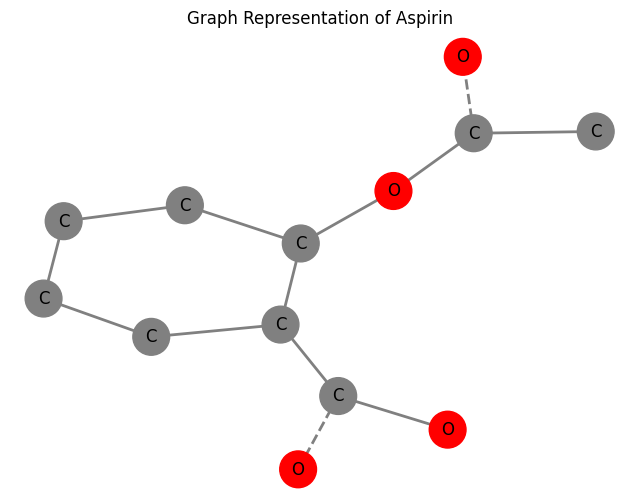

In [6]:

## --- Example molecule conversion ---
SMILES = 'CC(=O)OC1=CC=CC=C1C(=O)O'  # Acetylsalicylic acid (Aspirin)
g: nx.Graph = graph_from_smiles(SMILES)
    
# We can then create a visualization of the graph using matplotlib and networkx
# as well as the custom "draw_graph" function which we have introduced above 
# exactly for this purpose.
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
draw_graph(g, ax)
plt.title('Graph Representation of Aspirin')
plt.axis('off')
plt.show()

**Pytorch Geometric Graph Representation.** In the end, we want to use the graph structures as inputs to graph neural network models. In the `pytorch_geometric` library this requires the construction of a `Data` object to represent each of the graph structures. The function `data_from_graph` below therefore handles the conversion of `networkx.Graph` objects to `pytorch_geometric.Data` objects.

In the default case, a Data object requires knowledge about the following 3 attributes:

- `x`: a pytorch tensor of the shape $(V, N)$ where $V$ is the number of nodes in the graph and $N$ is the number of features each node is represented by.
- `edge_index`: a pytorch tensor of the shape $(2, E)$ where $E$ is the number of edges of the graph. An example column of this vector might be $(2, 1)$ which indicates that a *directed* edge exists from node with index 2 to node with index 1.
- `edge_attr`: A pytorch tensor of the shape $(E, M)$ where $E$ is again the number of edges and $M$ is the number of features per edge. 

**📝 Bidirectional Edges.** By default, pytorch geometric works with *directional* edges. This means that in the example edge $(2, 1)$ from above there exists a connection from node 2 to node 1 but *no* direction back from node 1 to node 2. This would imply that messages in the graph neural networks can only flow in one direction as well. In certain graph-related applications this principle of directionality is an important feature of the domain. For chemistry-related applications, however, it makes more sense to consider *undirectional* edges, where information can flow regardless of the direction. In `pytorch_geometric` this can be achieved by not only including the edges $(2, 1)$ but also including the edge $(1, 2)$ explicitly. 

In [7]:

def data_from_graph(graph: nx.Graph) -> Data:
    """
    Convert a NetworkX graph to a PyTorch Geometric Data object.
    
    IMPORTANT: This function creates BIDIRECTIONAL edges, which is required for 
    proper message passing in PyTorch Geometric GNNs. NetworkX undirected graphs 
    store each edge once, but PyG expects both (u,v) and (v,u) to be present.
    
    :param graph: A NetworkX Graph object with node and edge attributes.
    :returns: A PyTorch Geometric Data object.
    """
    node_attributes = np.array([
        data['node_attributes'].tolist() for _, data in graph.nodes(data=True)
    ])
    
    # Create BIDIRECTIONAL edges - PyTorch Geometric expects both directions
    # for undirected graphs to enable proper message passing
    # Practially this is done by just inserting each edge from the networkx graph 
    # into the torch edge list twice - once for each direction, where both share 
    # the same edge attributes.
    edge_indices = []
    edge_attributes = []
    for (u, v, data) in graph.edges(data=True):
        # Add edge in both directions
        edge_indices.append((u, v))
        edge_indices.append((v, u))
        # Same attributes for both directions (symmetric)
        edge_attributes.append(data['edge_attributes'].tolist())
        edge_attributes.append(data['edge_attributes'].tolist())
    
    edge_indices = np.array(edge_indices) if edge_indices else np.zeros((0, 2), dtype=np.int64)
    edge_attributes = np.array(edge_attributes) if edge_attributes else np.zeros((0, 0), dtype=np.float32)
    
    data = Data(
        x=torch.tensor(node_attributes, dtype=torch.float32),
        # NOTE: We transpose (.T) the edge index list here to have the shape 
        # (2, num_edges) as expected by the Pytorch Geometric Data class format!
        edge_index=torch.tensor(edge_indices.T, dtype=torch.long),
        # Contrary to the edge_index tensor, the edge_attr tensor has to be the 
        # shape (num_edges, num_edge_features).
        edge_attr=torch.tensor(edge_attributes, dtype=torch.float32),
    )
    
    # If the graph has a 'graph_labels' attribute, we can attach it to the data 
    # object as well.
    if graph.graph.get('graph_labels') is not None:
        data.y = torch.tensor(graph.graph['graph_labels'], dtype=torch.float32)
    
    return data
    
    
## --- Example conversion to PyG Data ---

data: Data = data_from_graph(g)
print('Graph Data Object')
print('=================')
print(data, '\n')
print(f'{data.x.size(0)} nodes with {data.x.size(1)} features each')
print(f'{data.edge_index.size(1)} edges (twice the number of bonds because bidirectional)')
print(f'with {data.edge_attr.size(1)} edge attributes each')
print()

Graph Data Object
Data(x=[13, 12], edge_index=[2, 26], edge_attr=[26, 6]) 

13 nodes with 12 features each
26 edges (twice the number of bonds because bidirectional)
with 6 edge attributes each



### Graph Neural Network Property Prediction

To implement the *Graph Neural Network (GNN)* model itself, we will do so using the popular [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) and further wrapping the model using [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/).

**Graph Neural Networks.** An *exhaustive* introduction of graph neural networks would exceed the scope of this tutorial series, but can be found in various online resources such as this [Gentle Introduction to Graph Neural Networks](https://distill.pub/2021/gnn-intro/) or the [Pytorch Geometric Documentation](https://pytorch-geometric.readthedocs.io/en/2.3.0/tutorial/create_gnn.html). Roughly speaking, graph neural networks address the important problem of working with *dynamic data structures*. Unlike in image processing - where all images already have or can be cropped to the exact same size - many other application domains need to work with data of vastly different sizes and formats. In chemistry, for instance, molecules come in all kinds of different shapes and sizes &mdash; from small drug-like molecules up to large protei structures. Trying to process instances with such different scales presents a considerable problem for machine learning models.

**Local Message Passing.** Graph neural networks solve this issue by moving the application of the neural network from the global graph-wide level to the *local* level. These networks dont operate directly on the graph itself, but are rather used to learn how to update the feautures of the individual *nodes* based on their locally neighboring nodes. In each "layer" of a GNN this is done such that each node receives "messages" from each of its direct neighbors containing information about their current state. Based on this aggregation of its neighbor states, a neural network is then used to update the state of the current node. After $L$ cycles of these local updates, the resulting representations of the individual nodes are compressed via an often simple aggregation function (e.g. the sum or average) and then further processed by neural networks to predict various graph-global properties.

**Pytorch Geometric.** PyG is a popular *framework* wich provides lots of useful utility functions, existing implementations and guidelines for the development of graph neural networks, specifically. To create a GNN model, one can create a custom subclass of the default `torch.nn.Module` and select message passing layers from a broad selection of pre-implemented choices. For this example, we'll use the [GINEConv](https://arxiv.org/abs/1810.00826) layer due to its capability of utilizing edge features. After defining the basic architecture &mdash; including the message passing layers, the aggregation function and the prediction network &mdash; one has to define the `forward(data: Data) -> torch.Tensor` method which implements the exact way in which the network's components are applied to a mapping from the original graph structure to the (singular) prediction of the desired property.


In [8]:
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import SumAggregation

# --- Torch Module ---
# The base torch module which implements the graph neural network itself.

class SimpleGNNModel(nn.Module):
    """
    Native PyTorch GNN model that outputs a single continuous value (regression).

    This is the core model architecture without any training logic. It can be
    used directly with explanation methods like GNNExplainer.

    For regression, this model outputs one raw, unbounded value per graph.
    """

    def __init__(self,
                 input_dim: int,
                 edge_dim: int,
                 hidden_units: int = 64,
                 edge_units: int = 64,
                 dense_units: list[int] = [64, 32],
                 output_dim: int = 1,
                 ) -> None:

        super().__init__()
        self.input_dim = input_dim
        self.edge_dim = edge_dim
        self.edge_units = edge_units
        self.hidden_units = hidden_units
        self.dense_units = dense_units
        self.output_dim = output_dim

        ## --- Define model architecture ---

        self.lay_embedd = nn.Linear(input_dim, hidden_units)
        self.lay_embedd_edge = nn.Linear(edge_dim, edge_units)

        ## --- graph convolutional layers ---

        self.lay_conv_1 = GINEConv(
            nn=nn.Sequential(
                nn.Linear(hidden_units, hidden_units),
                nn.LayerNorm(hidden_units),
                nn.ReLU(),
                nn.Linear(hidden_units, hidden_units),
                nn.LayerNorm(hidden_units),
                nn.LeakyReLU()
            ),
            edge_dim=edge_units,
        )
        self.lay_conv_2 = GINEConv(
            nn=nn.Sequential(
                nn.Linear(hidden_units, hidden_units),
                nn.LayerNorm(hidden_units),
                nn.ReLU(),
                nn.Linear(hidden_units, hidden_units),
                nn.LayerNorm(hidden_units),
                nn.LeakyReLU()
            ),
            edge_dim=edge_units,
        )
        self.lay_conv_3 = GINEConv(
            nn=nn.Sequential(
                nn.Linear(hidden_units, hidden_units),
                nn.LayerNorm(hidden_units),
                nn.ReLU(),
                nn.Linear(hidden_units, hidden_units),
                nn.LayerNorm(hidden_units),
                nn.LeakyReLU()
            ),
            edge_dim=edge_units,
        )
        self.conv_layers = [
            self.lay_conv_1,
            self.lay_conv_2,
            self.lay_conv_3
        ]

        ## --- global pooling layer ---
        self.lay_pool = SumAggregation()

        ## --- dense layers ---
        _hidden = hidden_units
        self.dense_layers = nn.ModuleList()
        for units in dense_units:
            lay_dense = nn.Sequential(
                nn.Linear(_hidden, units),
                nn.LayerNorm(units),
                nn.ReLU()
            )
            self.dense_layers.append(lay_dense)
            _hidden = units

        self.lay_out = nn.Linear(_hidden, output_dim)

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        batch,
        edge_weight=None
    ) -> torch.Tensor:
        """
        Forward pass that returns a RAW continuous prediction (no activation).

        :returns: Tensor of shape (batch_size, output_dim) containing the raw
            predicted values. For single-target regression output_dim == 1.
        """

        # Embedding the node and edge features
        edge_embedding = self.lay_embedd_edge(edge_attr)
        node_embedding = self.lay_embedd(x)

        # Graph convolution / message passing layers
        for lay_conv in self.conv_layers:
            node_embedding = lay_conv(
                x=node_embedding,
                edge_index=edge_index,
                edge_attr=edge_embedding,
            )

        # Global sum pooling
        graph_embedding = self.lay_pool(node_embedding, batch)

        # Dense prediction layers
        output = graph_embedding
        for lay_dense in self.dense_layers:
            output = lay_dense(output)

        # Final linear layer produces the raw regression output. For regression
        # we intentionally apply NO final activation (no softmax/sigmoid) so the
        # model can predict the unbounded, continuous logS value directly.
        output = self.lay_out(output)

        return output

    def copy(self) -> "SimpleGNNModel":
        """
        This method returns a new, copied instance of the graph neural network, with
        the same functions and same parameters.

        :returns: A new instance of the SimpleGNNModel class
        """

        # Practically we can achieve this copy process by first instantiating a new
        # "empty" model instance with the same parameters as the current model.
        # Then the "load_state_dict" functionality of the nn.Module base class can
        # be used to populate all of the internal model weights with the model weights
        # of the current model - effectively resulting in a copy.
        model = self.__class__(
            input_dim=self.input_dim,
            edge_dim=self.edge_dim,
            hidden_units=self.hidden_units,
            edge_units=self.edge_units,
            dense_units=self.dense_units,
            output_dim=self.output_dim
        )
        model.load_state_dict(self.state_dict())
        return model

<details style="border: 1.5px #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 The purpose of the <code>copy</code> method</summary>

You may have seen the <code>copy</code> method implemented for the <code>SimpleGNNModel</code> class above. Its purpose is to create an identical copy of the copy of the model, including the same methods and same parameters.

You'll also observe in the code following below that this copy method is used to provide a copy of the model for each of the explanation methods. So instead of applying all of the explanation methods on the same <em>instance</em> of the model, the explanations are generated based on <em>copies</em> of the same model.

The practical reason for doing these copy operations is to prevent <em>side effects</em>. In general, side effects refer to an often undesirable phenomenon when dealing with state-based objects. Some object instance might be passed on to various functions that perform operations based on this instance. Ideally, these functions would implement purely input-output behavior - only <em>reading</em> the state of the instance, performing computations and returning the result. Some functions, however, also need to, or accidentally, modify the state of the given object instances as well. Especially in cases where these state modifications are not explicitly documented, this can easily lead to complex errors further down the line - where it is assumed that the instances are in a certain state <em>A</em> but are really in state <em>B</em> because they have been silently modified previously.

In fact, side effects present a very real issue in the implementations of this tutorial notebook. Without using the copy operation, all of the explanation methods would be applied to the same instance of the model. The explanation functionality implemented in the <code>pytorch_geometric.explain</code> package internally relies on state-manipulation of the model, primarily in the form of <em>masking</em> certain edges during the message passing operations. When the <code>GNNExplainer</code> is applied to the model, it modifies the model's internal state. Without working on a fresh copy, these modifications could carry over and interfere with subsequent applications of the explainer - causing it not to work properly.

Regardless of whether an actual problem has already manifest itself or not, keeping the possibility of side effects in mind and guarding against it - e.g. by using copies where possible - is generally a good practice to follow when developing complex processing pipelines. 

</details>

Defining the GNN model itself only completes half of the required work, however. Aside from the model, one also has to take care of defining the *training process*, including the choice of the optimizer, the various hyperparameters, the loss functions and the way in which the gradients of the loss function are used to update the model weights.

**Pytorch Lightning.** Although all of the above is possible in pytorch itself, much of the required code is often simply repeated between different projects. [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) is a library which simplifies much of the implementation effort into more organized structures. To make use of Lightning's implementation of model training, we need to wrap the previously defined GNN model in a `LightningModule` class which not only defines a `forward` method but also defines additional methods such as `training_step` and `configure_optimizers` regarding the training process itself.

In [9]:

class SimpleRegressor(pl.LightningModule):
    """
    PyTorch Lightning wrapper around SimpleGNNModel for training a regressor.

    This class handles training/validation logic, loss computation, metrics,
    and optimizer configuration. The actual model architecture is contained
    in the `model` attribute (a SimpleGNNModel instance).

    For explanation methods (GNNExplainer), use `self.model` directly
    to access the native PyTorch module.
    """

    def __init__(self,
                 input_dim: int,
                 edge_dim: int,
                 hidden_units: int = 64,
                 edge_units: int = 64,
                 dense_units: list[int] = [64, 32],
                 output_dim: int = 1,
                 learning_rate: float = 1e-4,
                 ) -> None:

        super().__init__()
        self.learning_rate = learning_rate
        self.save_hyperparameters()

        # Create the underlying native PyTorch model
        self.model = SimpleGNNModel(
            input_dim=input_dim,
            edge_dim=edge_dim,
            hidden_units=hidden_units,
            edge_units=edge_units,
            dense_units=dense_units,
            output_dim=output_dim,
        )

        # Mean squared error loss for continuous-value regression
        self.criterion = nn.MSELoss()
        # Regression metrics: R2 (coefficient of determination) and mean absolute error
        self.metric_r2 = R2Score()
        self.metric_mae = MeanAbsoluteError()

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        batch,
        edge_weight=None
    ) -> torch.Tensor:
        """
        Forward pass delegated to the underlying model.

        :returns: Tensor of shape (batch_size, output_dim) containing the raw predictions
        """
        return self.model(x, edge_index, edge_attr, batch, edge_weight)

    def training_step(self, batch: Data, batch_idx: int) -> torch.Tensor:
        """
        Training step using mean squared error on the continuous target.
        """
        batch_size = torch.max(batch.batch) + 1

        # Forward pass returns the raw predicted values of shape (batch_size, 1)
        output: torch.Tensor = self(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch
        )

        # MSELoss between the flattened prediction and the continuous target
        loss: torch.Tensor = self.criterion(output.view(-1), batch.y.view(-1))

        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, batch_size=batch_size)

        return loss

    def validation_step(self, batch: Data, batch_idx: int) -> None:
        """
        Validation step computing R2 and MAE from the continuous predictions.
        """
        output: torch.Tensor = self(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.batch
        )

        preds = output.view(-1)
        targets = batch.y.view(-1)

        self.metric_r2.update(preds, targets)
        self.metric_mae.update(preds, targets)

    def on_validation_epoch_end(self) -> None:
        self.log('val_r2', self.metric_r2.compute(), prog_bar=True, on_step=False, on_epoch=True)
        self.log('val_mae', self.metric_mae.compute(), prog_bar=True, on_step=False, on_epoch=True)
        self.metric_r2.reset()
        self.metric_mae.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=1e-5
        )
        return optimizer

    def forward_graphs(self,
                       graphs: list[nx.Graph],
                       batch_size: int = 32
                       ) -> list[np.ndarray]:
        """
        Convenience method for batch inference on a list of graphs.
        Returns the raw predicted values for each graph.
        """
        with torch.no_grad():

            data_list: list[Data] = [data_from_graph(graph) for graph in graphs]
            loader = DataLoader(data_list, batch_size=batch_size, shuffle=False)

            results: list[np.ndarray] = []

            for batch in loader:
                output = self(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                output_np = output.detach().cpu().numpy()

                for out in output_np:
                    results.append(out)

            return results

**Converting Dataset.** Before being able to start the model training, we need to convert the dataset into the suitable representation using the `graph_from_smiles` and `data_from_graph` functions.


In [10]:
# First we can use the `graph_from_smiles` function to convert the SMILES strings in the dataset into networkx graph 
# objects.
data_frame['graph'] = data_frame['smiles'].apply(graph_from_smiles)

# Some AqSolDB entries are salts or mixtures (disconnected SMILES like "CC(=O)[O-].[Na+]")
# or single atoms. These produce graphs with multiple components and/or isolated nodes,
# which the MEGAN explanation model cannot handle (its edge-attention node importance is
# undefined for atoms without bonds). We therefore keep only molecules whose graph is a
# single connected component with more than one atom (and that parsed successfully).
data_frame = data_frame[
    data_frame['graph'].apply(
        lambda g: g is not None and g.number_of_nodes() > 1 and nx.is_connected(g)
    )
].reset_index(drop=True)

# However, we also want to attach the target values (stored in the "solubility" column of the data frame) to the graph objects 
# as this is needed for the conversion to the Data object format used by Pytorch Geometric.
for idx, row in data_frame.iterrows():
    row['graph'].graph['graph_labels'] = row['solubility']

print(f'Retained {len(data_frame)} connected molecules (single-fragment, with bonds)')
data_frame.head()

Retained 9887 connected molecules (single-fragment, with bonds)


,index,ID,smiles,InChIKey,solubility,split,graph
0,0,A-10,Cc1cccc(C=C)c1,JZHGRUMIRATHIU-UHFFFAOYSA-N,-3.123150,1,"(0, 1, 2, 3, 4, 5, 6, 7, 8)"
1,1,A-100,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,ODJUOZPKKHIEOZ-UHFFFAOYSA-N,-4.952869,1,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,2,A-1000,O=C1CCCCCCCCCOCCCCCO1,MKEIDVFLAWJKMY-UHFFFAOYSA-N,-3.883849,1,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
3,3,A-1002,CCCCCCCCCCC(C)CCCCCCCC,FFVPRSKCTDQLBP-UHFFFAOYSA-N,-6.451105,1,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
4,4,A-1003,NC(=O)N=NC(N)=O,XOZUGNYVDXMRKW-UHFFFAOYSA-N,-3.546243,1,"(0, 1, 2, 3, 4, 5, 6, 7)"


In [11]:
# --- train-test split ---
# The regression target is continuous, so there are no classes to balance.
# We therefore use a simple random 80/20 train-test split.

all_indices = list(range(len(data_frame)))
random.seed(42)
random.shuffle(all_indices)

split_point = int(0.8 * len(all_indices))
train_indices = all_indices[:split_point]
test_indices = all_indices[split_point:]

# --- creating Data objects ---
# Now we can create a list of `Data` objects from the `graph` column of the `data_frame` using the
# `data_from_graph` function defined above.

data_list_train: list[Data] = [
    data_from_graph(data_frame.iloc[index]['graph'])
    for index in train_indices
]
data_list_test: list[Data] = [
    data_from_graph(data_frame.iloc[index]['graph'])
    for index in test_indices
]

# --- creating dataloaders ---

# Finally, we can create the `DataLoader` objects from both of these subset instances.
# Since these data loaders automatically handle the shuffling and batching of the data during training,
# they need to receive the batch size as a constructor argument. The `num_workers` argument specifies
# how many subprocesses to use for data loading. Together with a reasonable `prefetch_factor`, this
# ensures that the data is loaded efficiently during training - preventing performance bottlenecks.
loader_train = DataLoader(data_list_train, batch_size=64, shuffle=True, num_workers=4, prefetch_factor=3, drop_last=True)
loader_test = DataLoader(data_list_test, batch_size=32, shuffle=False)

<details style="border: 1.5px #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 PytorchGeometric Dataloaders and Graph Batching.</summary>

In <code>pytorch_geometric</code> the graphs are represented as individual <code>Data</code> objects and a dataset of molecules, for instance, can be seen as a list of such Data object. However, to train a PyG graph neural network one doesn't use raw lists of data objects but rather special <code>DataLoader</code> objects that are constructed from the former.

These <code>DataLoader</code> instances solve the hard problem of <em>graph batching</em>. Batching is a method that is employed to improve the computational efficiency of neural network training and describes the process of paralellizing the forward pass, loss calculation and subsequent model update across multiple samples, instead of having to process each sample individually. For data structures of fixed size &mdash; like in image processing &mdash; this simply boils down to introducing another dimension of the input tensor to contain these batched samples. This batched tensor can be passed through the model with minimal additional effort.

Since graph structures can have vastly different sizes, they cannot be easily accumulated into a fixed size tensor. Pytorch Geometric addresses this issue by <em>concatenating</em> the information of the individual samples instead of distributing it across a separate dimension of the tensor. However, without the clear seperation provided by the dimension, additional efforts needs to be invested to be able to correctly identify which values belong to which graph. For this purpose, an additional <code>data.batch</code> vector is added to the Data object which contains as many elements as there are nodes in the combined graph and which uniquely identify the graph that "owns" the corresponding node via integer indices.

This graph batching process including the concatenation of multiple graph structures and the creation of the <code>batch</code> index vector is handled by the <code>DataLoader</code> objects.

On the implementation side all of these complexities are neatly hidden from the user and the DataLoader objects provide an iterator interface, which allows to directly iterate over them with a "for" loop. Each iteration of this for loop yields such a graph batch, where all of the features are concatenated and assigned by batch indices.

</details>

**Instantiating the Model.** After defining the model architecture and converting the dataset, we can now instantiate the model itself in preparation of the training. To calculate the number of model weights, the model class requires information about the number of node and edge features present in the given dataset. We obtain these directly from an example element of the dataset.

In [12]:
example_data: Data = data_list_train[0]

num_node_features: int = example_data.x.shape[1]
num_edge_features: int = example_data.edge_attr.shape[1]

model = SimpleRegressor(
    input_dim=num_node_features,
    edge_dim=num_edge_features,
    hidden_units=128,
    dense_units=[128, 64, 32],
    output_dim=1,  # single continuous output for regression
    learning_rate=5e-4,
)

print('GNN Model')
print('=========')
print(f'{num_node_features} input node features')
print(f'{num_edge_features} input edge features')
print(f'{model.model.__class__.__name__} model with {model.__class__.__name__} Lightning wrapper')
print(f'{sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters')

GNN Model
12 input node features
6 input edge features
SimpleGNNModel model with SimpleRegressor Lightning wrapper
155,009 trainable parameters


**Model Training.** The instantiated model can then be trained using a Lightning `Trainer` object.

In [13]:
# PytorchLighting allows to use so called "Callback" instances during the model 
# training which make it possible to execute custom code during specific stages of 
# the training process. The "PrintLossCallback" which is imported here executes at the 
# end of each training epoch to print the current loss value at each n-th epoch to 
# the console so that the user can track the training progress in real time.
from xai_chem_review.utils import PrintLossCallback

trainer = pl.Trainer(
    max_epochs=150,
    # The "accelerator" is the device on which the training should happen. Its possible 
    # to either define CPU or GPU here. The setting "auto" will select the 
    # best one which is availbe automatically.
    accelerator='auto',
    callbacks=[
        PrintLossCallback()
    ]
)

# The fit method actually executes the training and due to the PrintLossCallback
# will periodically print the progress of the loss value.
trainer.fit(
    model=model,
    train_dataloaders=loader_train,
    val_dataloaders=loader_test,
)

# Pytorch models can be in "training" mode or in "evalulation" (eval) mode. This mode 
# determines the behavior of a few selected layer types that are commonly used in 
# neural networks such as normalization or dropout layers.
# After completing the training, it is important to set the model in to evaluation 
# mode to ensure proper behavior.
model.eval()

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /media/ssd2/Programming/xai_chem_review/.venv/lib/py ...
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ SimpleGNNModel    │  155 K │ train │     0 │
│ 1 │ criterion  │ MSELoss           │      0 │ train │     0 │
│ 2 │ metric_r2  │ R2Score           │      0 │ train │     0 │
│ 3 │ metric_mae │ MeanAbsoluteError │      0 │ train │     0 │
└───┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 155 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 155 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 51                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/dat
a_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.

...

Epoch 135 | train_loss: 0.2125

Epoch 140 | train_loss: 0.2013

Epoch 145 | train_loss: 0.2086

`Trainer.fit` stopped: `max_epochs=150` reached.


SimpleRegressor(
  (model): SimpleGNNModel(
    (lay_embedd): Linear(in_features=12, out_features=128, bias=True)
    (lay_embedd_edge): Linear(in_features=6, out_features=64, bias=True)
    (lay_conv_1): GINEConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (5): LeakyReLU(negative_slope=0.01)
    ))
    (lay_conv_2): GINEConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (5): LeakyReLU(negative_slope=0.01)
    ))
    (lay_conv_3): GINEConv(nn=Sequential(
      (0): Linear(in_features=128, ou

**Model Evaluation.** Before using the model to generate explanations, we should evaluate its predictive performance on the test set. This ensures that we are explaining a model that has learned meaningful patterns from the data at all. The model at hand is a *regression* model, so we evaluate it using typical regression metrics such as the coefficient of determination (R²), the mean absolute error (MAE) and the root mean squared error (RMSE). These can be computed using the corresponding functions from the `scikit-learn` library.

In [14]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- Evaluate model on test set ---

model.eval()

# Collect predictions and ground truth values
y_true = []
y_pred = []

with torch.no_grad():
    for batch in loader_test:

        batch = batch.to(model.device)
        # The model returns raw continuous predictions of shape (batch_size, 1)
        output = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)

        y_pred.extend(output.view(-1).cpu().numpy())
        y_true.extend(batch.y.view(-1).cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate regression metrics
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5

print('Model Evaluation on Test Set:')
print(f'  R2:   {r2:.4f}')
print(f'  MAE:  {mae:.4f}')
print(f'  RMSE: {rmse:.4f}')

Model Evaluation on Test Set:
  R2:   0.8677
  MAE:  0.5698
  RMSE: 0.8323


**🔍 Solubility Prediction Results.** At this point, the model should achieve an R² of roughly 0.7&ndash;0.85 on the test set. The exact value depends on the random train-test split, the model initialization and the number of training epochs. For reference, the practical ceiling reported in the literature for AqSolDB lies around R² ≈ 0.86&ndash;0.89, limited by experimental measurement noise. If your R² is substantially lower (e.g. below 0.5), it is advisable to raise the number of training epochs, or simply re-run the model training cells.

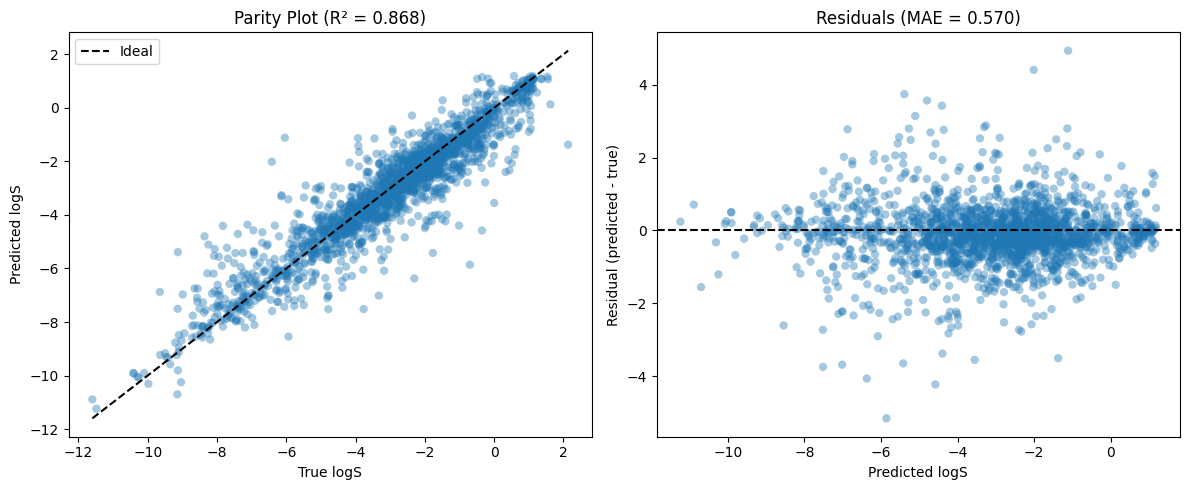

In [15]:
# --- Visualize evaluation results ---

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Parity plot: predicted vs. true logS
axes[0].scatter(y_true, y_pred, alpha=0.4, edgecolor='none')
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[0].plot(lims, lims, 'k--', label='Ideal')
axes[0].set_xlabel('True logS')
axes[0].set_ylabel('Predicted logS')
axes[0].set_title(f'Parity Plot (R² = {r2:.3f})')
axes[0].legend()

# Residual plot: residual vs. predicted logS
residuals = y_pred - y_true
axes[1].scatter(y_pred, residuals, alpha=0.4, edgecolor='none')
axes[1].axhline(0, color='k', linestyle='--')
axes[1].set_xlabel('Predicted logS')
axes[1].set_ylabel('Residual (predicted - true)')
axes[1].set_title(f'Residuals (MAE = {mae:.3f})')

plt.tight_layout()
plt.show()

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 2.2** $\cdot$ The GNN architecture choices significantly impact both prediction accuracy and the explanations that can be derived from the model. The current model uses 3 GINEConv layers with 128 hidden units.

Try modifying the model architecture:
1. Change `hidden_units` to 64 or 256
2. Modify `dense_units` to use fewer or more layers (e.g., `[64, 32]` vs `[128, 128, 64, 32]`)

After retraining, compare: (1) the test set R², and (2) whether the explanations from GNNExplainer highlight similar substructures. Do deeper/wider models produce more or less interpretable explanations?
</div>

**Generating Graph Explanations with PyG.** To generate explanations in the `pytorch_geometric.explain` framework, we firstly need to set up a generic `Explainer` class. In this class, one needs to specify the general *kind* of explanation to be generated, including the following parameters:

- `explanation_type`: distinguishes between "model" and "phenomenon", which influence with respect to which target property the explanations are being optimized. In the case of *"model"*, the explanations are being optimized to explain the model's prediction &mdash; even if they are incorrect.
- `node_mask_type`: Determines how the node explanations will look like. In the case of *"object"* nodes are masked as one unit &mdash; a node can either be marked as important, or not. Alternatives would allow only for individual features within the nodes to be masked and consequently be explained.
- `edge_mask_Type`: Determines how the edge explanations will look like in the same manner.
- `model_config`: This parameter provides the required information to the explainer of how the model works, in the first place.
    - `mode`: This defines what the purpose of the model was, which could either be classification of discrete classes or &mdash; as in this example &mdash; regression of continuous values.
    - `task_level`: Defines at which "level of granularity" the property is being predicted. The *"graph"* option, as given in this example, specifies that the target properties are predicted on the level of the graph as a whole. Alternatively, there are other kinds of graph neural networks to make predictions for the individual *nodes* or *edges* of a graph structure.

**Obtaining Explanations.** After properly setting up the `Explainer` class with all of the relevant information about the model as well as the options of what kinds of explanations are expected, one can generate an explanation by calling the explainer instance with the graph(s) of interest in the format of a PyG graph batch.

**📝 Creating single-graph batches with `DataLoader`.** The above cell below demonstrates how to prepare a single-graph batch. The reason why this is necessary is that the creation of an `Explanation` with the the `GNNExplainer` requires a batched `Data` object rather than an individual graph. Consequently, we need to batch all inputs &mdash; even if it is only a single graph. As seen above, this is done by constructing the individual `Data` object, handing it in a single-element list to the DataLoader and then calling the `next` function on the DataLoader iterator.

```python
data: Data = Data(...)
loader = DataLoader([data], batch_size=1)
batch: Data = next(iter(loader))
```

In [16]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer
from torch_geometric.explain.config import ModelConfig, ThresholdConfig

# Use the native torch module (model.model) for the explainer
# This avoids Lightning-specific wrappers that can interfere with explanation methods
explainer = Explainer(
    model=model.model.copy(),
    algorithm=GNNExplainer(epochs=300, lr=0.01, edge_size=5e-3, edge_ent=1.0),
    # 'model' explanations attribute the model's OWN predicted value - the target
    # is inferred automatically from the prediction, so no label needs to be passed.
    explanation_type='model',
    node_mask_type='object',
    edge_mask_type='object',
    model_config=ModelConfig(
        mode='regression',
        task_level='graph',
        return_type='raw',
    ),
)

In [17]:
# SMILES representation of the (illustrative) molecule to explain:
# it combines a polar ketone and hydroxyl group with a hydrophobic aromatic ring.
SMILES: str = 'CC(=O)Cc1ccc(O)cc1'

# We first convert the SMILES into the networkx Graph intermediate representation
graph: nx.Graph = graph_from_smiles(SMILES)
# This can then be converted in the pytorch_geometric Data representation of
# a graph structure.
data: Data = data_from_graph(graph)
# However, the explainer requires a *batched* graph to create the explanation
# We therefore use the DataLoader utility to turn the single-graph Data instance
# into a batched Data instance.
loader: DataLoader = DataLoader([data], batch_size=1, shuffle=False)
batch: Data = next(iter(loader))

# The explanation can be created by calling the explainer instance with
# the input sample of interest. Because the explainer was configured with
# explanation_type='model', the regression target is inferred from the model's
# own prediction and we do not pass a target explicitly.
explanation = explainer(
    x=batch.x,
    edge_index=batch.edge_index,
    edge_attr=batch.edge_attr,
    batch=batch.batch,
    index=0
)

print('Graph Explanation')
print('=================')
print(explanation)

Graph Explanation
Explanation(node_mask=[11, 1], edge_mask=[22], prediction=[1, 1], target=[1, 1], index=[1], x=[11, 12], edge_index=[2, 22], edge_attr=[22, 6], batch=[11])


**Visualization of Explanation Masks.** Upon calling the `Explainer` on the given graph, it returns an `Explanation` object containing the mask (explanation) values for all of the nodes and edges. However, to become useful to a human observer, this explanation will have to be *visualized* in some manner. The code below implements this visualization in two steps:

- *Adding the explanation to the `nx.Graph`.* This first step adds the information about the explanations to the networkx graph object representing the graph in question by adding an additional attribute `node_explanation` to each node and an additional value `edge_explanation` to each edge. This step is to simplify the subsequent visualization so that we only have to provide it the graph object.
- *Drawing the visualization into a plot.* The `draw_explanation` function then takes the graph, along with the position matrix to visualize the individual explanation mask values. This is done by painting colored sections behind the corresponding graph elements (circles for the nodes, thicker lines for the edges), where the transparency of the elements encodes the strength of the explanation: More colorful highlights indicate more important elements.

In [18]:
import matplotlib.colors as mcolors

# --- Adding Explanation to Graph ---

def graph_add_explanation(
    graph: nx.Graph,
    explanation,
) -> nx.Graph:
    """
    Attaches the information given by the `explanation` to the given `graph` 
    instance into the additional node/edge properties "node_explanation" and 
    "edge_explanation".
    
    :param graph: The networkx Graph instance to represent the graph
    :param explanation: The PyG explanation for that graph.
    
    :returns: The updated graph object
    """

    for node_idx, node_mask in enumerate(explanation.node_mask):
        graph.nodes[node_idx]['node_explanation'] = node_mask.detach().cpu().numpy()

    # For edge masks, average the masks from both directions (u,v) and (v,u)
    # since we have bidirectional edges but NetworkX stores edges once
    edge_masks_dict = {}
    for (u, v), edge_mask in zip(explanation.edge_index.t(), explanation.edge_mask):
        u_idx, v_idx = u.item(), v.item()
        key = (min(u_idx, v_idx), max(u_idx, v_idx))
        if key not in edge_masks_dict:
            edge_masks_dict[key] = []
        edge_masks_dict[key].append(edge_mask.detach().cpu().item())

    for (u, v), masks in edge_masks_dict.items():
        avg_mask = np.mean(masks)
        if graph.has_edge(u, v):
            graph.edges[(u, v)]['edge_explanation'] = avg_mask
        elif graph.has_edge(v, u):
            graph.edges[(v, u)]['edge_explanation'] = avg_mask

    return graph

# --- Explanation Visualization ---

def draw_explanation(
    graph: nx.Graph, 
    pos: dict, 
    ax: plt.Axes,
    node_key: str = "node_explanation",
    edge_key: str = "edge_explanation",
    diverging: bool = False,
    positive_color: str = "lightgreen",
    negative_color: str = "lightcoral",
) -> None:
    """
    Draws the explanation on the graph visualization.
    
    :param graph: The networkx graph with explanation attributes.
    :param pos: Dictionary of node positions.
    :param ax: The matplotlib axes to draw on.
    :param node_key: The key used to retrieve node explanation values from the graph.
        Default is "node_explanation".
    :param edge_key: The key used to retrieve edge explanation values from the graph.
        Default is "edge_explanation".
    :param diverging: If True, use diverging color scheme (green for positive, red for negative).
                      If False, use single color scheme (green for high values).
    :param positive_color: Color for positive/high importance values.
    :param negative_color: Color for negative importance values (only used if diverging=True).
    """
    white = np.array([1.0, 1.0, 1.0])
    pos_color = np.array(mcolors.to_rgb(positive_color))
    neg_color = np.array(mcolors.to_rgb(negative_color))
    
    for node, data in graph.nodes(data=True):
        
        if node_key in data:
            explanation_value = float(data[node_key])
            
            if diverging:
                # Diverging color scheme: negative -> red, zero -> white, positive -> green
                if explanation_value >= 0:
                    scaler = np.clip(explanation_value, 0.0, 1.0)
                    color = pos_color
                else:
                    scaler = np.clip(-explanation_value, 0.0, 1.0)
                    color = neg_color
            else:
                # Single color scheme: low -> white, high -> green
                scaler = np.clip(explanation_value, 0.0, 1.0)
                color = pos_color
            
            ax.scatter(
                pos[node][0], pos[node][1],
                s=1500, color=[color], alpha=float(scaler),
                zorder=-10
            )
            
    for u, v, data in graph.edges(data=True):
        
        if edge_key in data:
            explanation_value = float(data[edge_key])
            
            if diverging:
                if explanation_value >= 0:
                    scaler = np.clip(explanation_value, 0.0, 1.0)
                    color = pos_color
                else:
                    scaler = np.clip(-explanation_value, 0.0, 1.0)
                    color = neg_color
            else:
                scaler = np.clip(explanation_value, 0.0, 1.0)
                color = pos_color
            
            ax.plot(
                [pos[u][0], pos[v][0]], 
                [pos[u][1], pos[v][1]],
                color=color, alpha=float(scaler), 
                linewidth=15, 
                zorder=-20,
            )


/tmp/ipykernel_519009/1851284921.py:76: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  explanation_value = float(data[node_key])


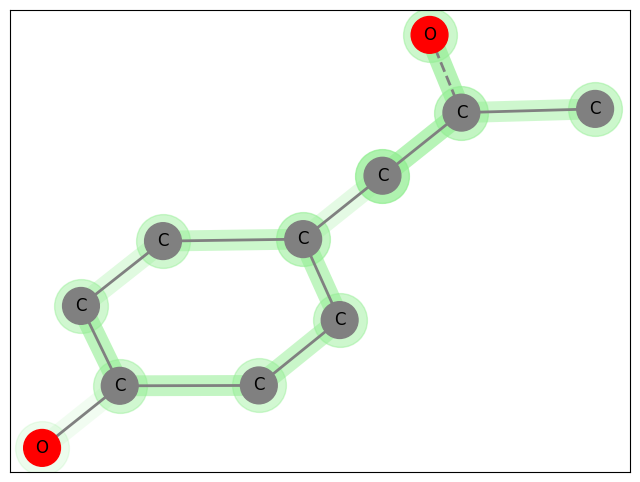

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# First we draw the graph itself onto the plot. This also provides the 
# vector of node positions within the plots coordinate system.
pos = draw_graph(graph, ax)

# Then the explanations are added to the background - behind the graph's
# nodes and edges.
graph_add_explanation(graph, explanation)
draw_explanation(graph, pos, ax)

**Interpreting the GNNExplainer Result.** A first thing to notice is that the explanation highlights *almost the entire molecule* &mdash; only with subtle differences in intensity. This points to a fundamental difficulty: for a *regression* target it is far from obvious what "important" is even supposed to mean. The soft mask only captures the *magnitude* of an atom's influence on the prediction, but says nothing about its *direction*. As a result, an atom that raises the predicted solubility (such as the polar hydroxyl group) and one that lowers it (such as the hydrophobic aromatic ring) are both simply flagged as "important", and end up indistinguishable in the heat-map. What we would really want for a property like solubility is some notion of *directionality* &mdash; which parts of the molecule support the property, and which parts push it the other way.

**Off-Distribution Perturbations.** A second limitation lies in the way the explanation is obtained in the first place. GNNExplainer works by softly masking node features &mdash; effectively scaling the features of "unimportant" atoms towards zero. For molecules this is a problematic operation: zeroing out an atom's features strips away its chemical identity, leaving behind a smaller, altered molecule that the model never actually saw during training. For properties that depend strongly on a molecule's overall size and composition (e.g. the aqueous solubility regarded here) such perturbations can be misleading, because the masked graph no longer corresponds to a comparable molecule in the first place.

These shortcomings are not unique to GNNExplainer, but they do motivate the alternative methods explored in the following sections, which are designed to address exactly these kinds of issues.

## **2.3** $\cdot$ 📚 *Valid, Sparse and Stable Explanations* (`ZORRO`)

The second post-hoc method we explore, *ZORRO*, was proposed by [Funke *et al.*](https://arxiv.org/abs/2105.08621) in 2021. We just saw one difficulty with *soft* masks like GNNExplainer's: when every atom is assigned a continuous importance value between 0 and 1, it is not always clear where to draw the line between an "important" and an "unimportant" atom. ZORRO instead searches for a *hard* mask. Rather than grading every atom on a continuum, it tries to identify a small, discrete *subset* of atoms that &mdash; on its own &mdash; is already sufficient to reproduce the model's prediction. The authors argue that such a binary "these atoms are what matter" answer is easier for a human to interpret than a continuous gradient, and they formalize three properties that a good hard-mask explanation should satisfy:

- **Validity** &mdash; the selected subset of atoms *alone* should be enough to arrive at (approximately) the same prediction the model makes for the full molecule. If the output can be recovered from just a handful of atoms, then those atoms carry the information the model relies on.
- **Sparsity** &mdash; that subset should be *small*. An explanation that selects half the molecule conveys very little; the value lies in pointing to a compact, focused group of atoms.
- **Stability** &mdash; the explanation should be *robust*. Changes to the atoms *outside* the selected set should not meaningfully alter the prediction: if replacing the rest of the molecule with other plausible atoms leaves the output intact, this confirms that the selected atoms are the ones that matter.

**RDT-Fidelity.** ZORRO combines these three requirements into a single objective called *RDT-Fidelity* (grounded in rate-distortion theory). It can be understood as a repeated experiment: a candidate subset of atoms is held fixed, and the *unselected* atoms are then replaced with random "noise" atoms drawn from the data distribution, recomputing the prediction each time. If the selected atoms genuinely determine the output, the prediction should change very little &mdash; regardless of what is substituted for the rest of the molecule. The RDT-Fidelity is the fraction of these random trials in which the prediction is preserved, so a value close to 1 indicates that the chosen atoms reliably reproduce the prediction on their own &mdash; capturing both the *validity* and the *stability* property at once.

**Greedy search.** It remains to actually find such a subset. Evaluating every possible combination of atoms would be computationally infeasible, so ZORRO constructs the explanation *greedily*: starting from an empty set, it adds the single atom that most increases the RDT-Fidelity, then the next-best atom, and so on, until the fidelity exceeds a user-defined threshold $\tau$. Since each step only adds the atom that contributes the most, the procedure tends to produce small selections, and the result is a sparse set of atoms that are *jointly* sufficient for the prediction. As with GNNExplainer, the procedure is *post-hoc* and *model-agnostic*: it explains our already-trained regression GNN by probing how it behaves, without modifying or retraining it.

### Implementation

We use the [zorrito](https://github.com/the16thpythonist/zorrito) package, a modern PyTorch-Geometric reimplementation of ZORRO that extends the original (node-classification) formulation with **graph-level** prediction and **regression** support &mdash; exactly what we need to explain our whole-molecule solubility model. Because ZORRO only ever perturbs the *node* features and keeps the graph structure fixed, we wrap our trained GNN in a small `ZorroModelWrapper` that re-supplies the molecule's constant edge features on every call. We also hand the explainer a `noise_pool` of real atom feature vectors sampled from the training set, so that the random replacements used to compute the RDT-Fidelity stay chemically plausible; whole-row sampling (`noise_mode='row'`) keeps the one-hot atom-type encoding valid.

**The tolerance band and directions.** For classification, ZORRO counts a perturbation trial as "preserved" when the predicted *class* is unchanged. Regression has no classes, so `zorrito` instead checks whether the perturbed prediction stays inside a **tolerance band** of half-width $\varepsilon$ (the `tolerance` argument, in logS units) around the original prediction. The `direction` argument then decides which side of that band has to be respected:

- `direction='both'` &mdash; a trial is preserved if the prediction stays within $\pm\varepsilon$. This is the symmetric "selected atoms are sufficient to reproduce the value" reading.
- `direction='down'` &mdash; only *drops* below $-\varepsilon$ break the trial, so ZORRO selects the atoms that keep the prediction from **falling**: the solubility-*supporting* atoms.
- `direction='up'` &mdash; only *rises* above $+\varepsilon$ break the trial, selecting the atoms that keep the prediction from **rising**: the solubility-*limiting* atoms.

Running ZORRO once with `'down'` and once with `'up'` therefore yields a directional pair of explanations. The width $\varepsilon$ is the main "resolution" knob: a *tight* band (e.g. `0.2`) demands that the selected atoms reproduce the prediction very precisely and so tends to select *more* atoms, while a *loose* band (e.g. `1.0`) is easier to satisfy and yields sparser selections.

**Controlling the greedy search.** The remaining knobs govern the greedy selection itself and its fidelity estimate. `fidelity_threshold` is the target RDT-Fidelity $\tau$ at which the search stops adding atoms (`0.85` by default, `0.9` in the run below); raising it towards `0.95` forces a more faithful &mdash; but less sparse &mdash; explanation. Because the RDT-Fidelity is itself a *Monte-Carlo* estimate, `samples` sets how many random noise trials are averaged per evaluation (higher = less noisy fidelity, but slower), and `top_k` bounds how many candidate atoms are scored at each greedy step. Finally, `select` chooses *what* is explained: `'nodes_only'` restricts the search to atoms (the structure-only view we use here), whereas `'both'` additionally returns a *feature* mask identifying which atom features (atom-type, valence, charge, ...) are essential to the prediction.## **2.3** $\cdot$ 📚 *Valid, Sparse and Stable Explanations* (`ZORRO`)

In [20]:
from zorrito import Zorro

# ZORRO calls the model as `model(x, edge_index, batch)` and only perturbs the NODE
# features. Our GNN, however, also requires the edge features (`edge_attr`). Since ZORRO
# keeps the molecular graph (and therefore its bonds) fixed, we can wrap the trained model
# in a small adapter that supplies the molecule's fixed edge features on every call.
class ZorroModelWrapper(nn.Module):

    def __init__(self, base_model: SimpleGNNModel, edge_attr: torch.Tensor):
        super().__init__()
        self.base_model = base_model
        self.edge_attr = edge_attr

    def forward(self, x, edge_index, batch):
        return self.base_model(x, edge_index, self.edge_attr, batch)


# ZORRO replaces unselected atoms with "noise" atoms. We give it a dataset-wide pool of
# real atom feature vectors (sampled from the training molecules) so that the perturbed
# inputs stay chemically plausible. Whole-row sampling (`noise_mode='row'`) keeps the
# one-hot atom-type encoding valid.
_all_train_nodes = torch.cat([d.x for d in data_list_train], dim=0)
_perm = torch.randperm(_all_train_nodes.shape[0])[:5000]
zorro_noise_pool = _all_train_nodes[_perm].cpu()


def zorro_explain(smiles: str,
                  base_model: SimpleGNNModel,
                  direction: str = 'both',
                  tolerance: float = 0.5,
                  samples: int = 100,
                  top_k: int = 8,
                  fidelity_threshold: float = 0.85,
                  ) -> tuple[np.ndarray, float]:
    """
    Run ZORRO on a single molecule and return the (hard) atom selection mask.

    :param smiles: SMILES string of the molecule to explain.
    :param base_model: The trained native GNN module (SimpleGNNModel).
    :param direction: 'both', 'up' or 'down' (see the regression tolerance band above).
    :param tolerance: Half-width epsilon of the tolerance band, in logS units.
    :param samples: Number of Monte-Carlo noise trials per RDT-Fidelity estimate.
    :param top_k: Number of top candidate atoms evaluated per greedy step.
    :param fidelity_threshold: Target RDT-Fidelity tau at which the greedy search stops.
    :returns: A tuple of (node_mask, fidelity) where node_mask is a float array of shape
        (num_nodes,) with 1.0 for selected atoms and 0.0 otherwise.
    """
    # Everything runs on the CPU for simplicity and to avoid device-mismatch issues.
    device = torch.device('cpu')
    base_model = base_model.to(device).eval()

    graph = graph_from_smiles(smiles)
    data = data_from_graph(graph)

    # Adapter that supplies this molecule's fixed edge features to the GNN.
    wrapper = ZorroModelWrapper(base_model, data.edge_attr.to(device))

    explainer = Zorro(
        model=wrapper,
        task='graph',                  # graph-level (whole-molecule) prediction
        objective='regression',        # continuous target -> tolerance-band match
        select='nodes_only',           # structure-only: select atoms, not features
        direction=direction,
        tolerance=tolerance,
        noise_mode='row',              # whole-row sampling keeps one-hot features valid
        noise_pool=zorro_noise_pool,
        device='cpu',
        samples=samples,
        top_k=top_k,
        seed=42,
    )
    explanations = explainer.explain(
        x=data.x.to(device),
        edge_index=data.edge_index.to(device),
        fidelity_threshold=fidelity_threshold,
        max_explanations=1,
    )
    explanation = explanations[0]
    node_mask = explanation.node_mask.detach().cpu().numpy().astype(float)
    return node_mask, float(explanation.fidelity)


def graph_set_node_mask(graph: nx.Graph, mask: np.ndarray, node_key: str = "node_explanation") -> None:
    """Attach a per-node (hard or soft) mask to a networkx graph for visualization."""
    for i in range(min(len(mask), graph.number_of_nodes())):
        graph.nodes[i][node_key] = float(mask[i])

**Directional ZORRO Explanations.** We now apply ZORRO to the same molecule used for the GNNExplainer example, once for each direction. The `direction='down'` run highlights the atoms required to keep the predicted solubility from *falling* (the atoms that support solubility), while `direction='up'` highlights the atoms that keep it from *rising* (the atoms that limit solubility). Because ZORRO returns a *hard* mask, each atom is either fully selected or not &mdash; there are no intermediate shades as there are for GNNExplainer.

Molecule: CC(=O)Cc1ccc(O)cc1
direction='down' (keeps solubility from falling): 2 atoms selected, RDT-Fidelity=0.910
direction='up'   (keeps solubility from rising):  3 atoms selected, RDT-Fidelity=0.930


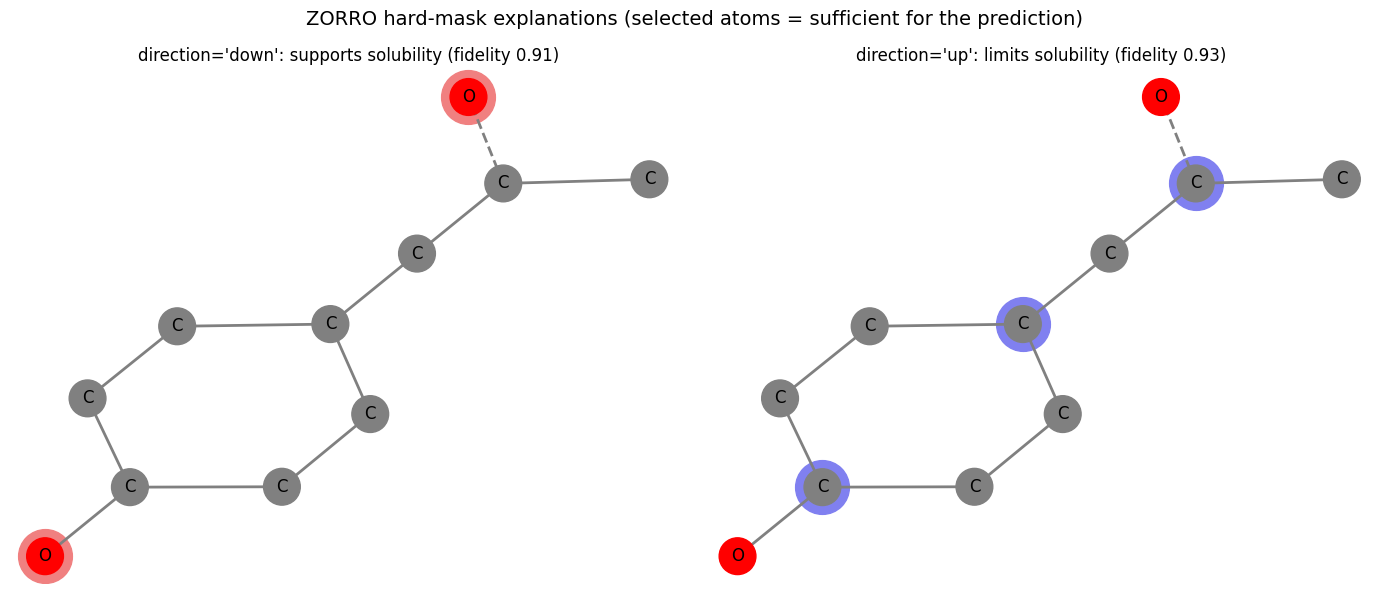

In [21]:
# Use the same molecule as in the GNNExplainer example for a direct comparison.
zorro_smiles = 'CC(=O)Cc1ccc(O)cc1'

# ZORRO explains the trained GNN (we use a fresh copy of the native module).
zorro_base_model = model.model.copy()

# Atoms that keep the prediction from FALLING  -> solubility-supporting atoms
mask_down, fid_down = zorro_explain(zorro_smiles, zorro_base_model, direction='down', tolerance=0.3, fidelity_threshold=0.9)
# Atoms that keep the prediction from RISING   -> solubility-limiting atoms
mask_up, fid_up = zorro_explain(zorro_smiles, zorro_base_model, direction='up', tolerance=0.3, fidelity_threshold=0.9)

print(f'Molecule: {zorro_smiles}')
print(f"direction='down' (keeps solubility from falling): {int(mask_down.sum())} atoms selected, RDT-Fidelity={fid_down:.3f}")
print(f"direction='up'   (keeps solubility from rising):  {int(mask_up.sum())} atoms selected, RDT-Fidelity={fid_up:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: direction='down' -> supports solubility -> red
graph_down = graph_from_smiles(zorro_smiles)
graph_set_node_mask(graph_down, mask_down)
pos = draw_graph(graph_down, axes[0])
draw_explanation(graph_down, pos, axes[0], positive_color='lightcoral')
axes[0].set_title(f"direction='down': supports solubility (fidelity {fid_down:.2f})")
axes[0].axis('off')

# Panel 2: direction='up' -> limits solubility -> blue
graph_up = graph_from_smiles(zorro_smiles)
graph_set_node_mask(graph_up, mask_up)
pos = draw_graph(graph_up, axes[1])
draw_explanation(graph_up, pos, axes[1], positive_color='#8080F0')
axes[1].set_title(f"direction='up': limits solubility (fidelity {fid_up:.2f})")
axes[1].axis('off')

plt.suptitle('ZORRO hard-mask explanations (selected atoms = sufficient for the prediction)', fontsize=14)
plt.tight_layout()
plt.show()

**Interpreting ZORRO Explanations.** The two panels above highlight a key difference from GNNExplainer. Rather than a continuous heat-map of importance, ZORRO returns a small, *binary* set of atoms that is by itself *sufficient* to reproduce the prediction (to within the tolerance band) even when every other atom is randomized. The reported *RDT-Fidelity* quantifies how reliably the selection preserves the prediction across these random perturbations &mdash; the greedy search keeps adding atoms until this value crosses the threshold $\tau$ (here $0.9$).

The directional split makes the result chemically readable: the `direction='down'` selection tends to pick up polar, solubility-supporting groups (e.g. the hydroxyl and ketone), whereas `direction='up'` tends to pick up the hydrophobic aromatic core that limits solubility. Because the mask is hard and sparse, there is no ambiguity about *which* atoms are claimed to matter &mdash; the trade-off is that ZORRO tells us *that* a compact atom set is sufficient, but not the graded importance of atoms within it.

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 2.3** $\cdot$ ZORRO's explanations depend on two key knobs: the tolerance band `tolerance` (how much prediction change still counts as "preserved") and the stopping threshold `fidelity_threshold` ($\tau$). Try (1) tightening the tolerance (e.g. `0.2`) and loosening it (e.g. `1.0`), and (2) raising the threshold towards `0.95`. How do the number of selected atoms and the resulting fidelity change?
</div>

## **2.4** $\cdot$ 📚 *Multi-Explanation Graph Attention Network* (`MEGAN`)

The final structure-attribution method we'll explore takes a fundamentally different approach: rather than explaining predictions *post-hoc*, it produces explanations as an **intrinsic part of the forward pass**. The *Multi-Explanation Graph Attention Network* (MEGAN) was proposed by [Teufel *et al.*](https://link.springer.com/chapter/10.1007/978-3-031-44067-0_18) in 2023 and is implemented in the [graph_attention_student](https://github.com/aimat-lab/graph_attention_student) package. One core advantage of such an intrinsic method is the *runtime*. Post-hoc methods such as GNNExplainer and ZORRO may require substantial additional runtime for each explanation, while a self-explaining method produces it directly as a byproduct of it's own forward pass.

**Core Methodology.** MEGAN is built on graph attention mechanisms where the attention weights serve a dual purpose: they both guide information flow during message passing *and* directly constitute the explanation. The key innovation lies in the use of **multiple explanation channels** &mdash; parallel attention heads that capture different aspects of the prediction. For regression tasks, two channels are used: one highlighting substructures that contribute *positively* to the prediction and another highlighting substructures that contribute *negatively*. For classification tasks, the number of channels matches the number of classes, with each channel highlighting features relevant to that particular class.

The architecture consists of several components:
1. **Parallel attention encoder**: Multiple layers of graph attention, where each layer contains K parallel attention heads (one per explanation channel). The attention weights from each head determine both the message passing and the node/edge importance for that channel.
2. **Importance-weighted pooling**: Rather than simple sum or mean pooling, MEGAN uses the attention weights to perform a weighted aggregation of node embeddings into a graph embedding &mdash; separately for each channel.
3. **Channel-specific projections**: Each channel's graph embedding is independently projected before being concatenated for the final prediction.

**Comparison to Other Methods.** Unlike GNNExplainer and ZORRO, which require a separate explanation step after prediction, MEGAN produces explanations *simultaneously* with the prediction. This has several advantages: (1) explanations are always consistent with the prediction since they use the same attention weights, (2) no additional computation is needed for explanation, and (3) the model can be trained with *explanation supervision* when ground-truth explanations are available, potentially improving both prediction accuracy and explanation quality.

The multi-channel nature of MEGAN explanations is particularly valuable for understanding complex structure-activity relationships. In molecular property prediction, different functional groups may contribute opposing effects (e.g., hydrophilic vs. hydrophobic groups for solubility), and MEGAN's separate channels can capture these distinct contributions.

**Implementation.** The `graph_attention_student` package provides a PyTorch Lightning-based implementation that integrates seamlessly with PyTorch Geometric data structures. The model can be trained on any graph-level regression or classification task.

**📝 Note.** Since MEGAN is a complete model architecture rather than a post-hoc explanation method, we cannot apply it to our existing `SimpleRegressor` model. Instead, we'll train a new MEGAN model on the same dataset and compare the explanations it produces.

In [22]:
from graph_attention_student.torch.megan import Megan
from visual_graph_datasets.processing.molecules import MoleculeProcessing

# --- Setting up MEGAN-compatible data processing ---
# MEGAN uses its own data processing pipeline from the visual_graph_datasets package.
# This processing creates node and edge features optimized for the MEGAN architecture.

processing = MoleculeProcessing()

# We'll convert our SMILES strings into the format expected by MEGAN
def graph_dict_from_smiles(smiles: str) -> dict:
    """
    Converts a SMILES string into a graph dictionary compatible with MEGAN.
    
    :param smiles: The SMILES string of the molecule.
    :returns: A dictionary containing graph data (node_indices, node_attributes, 
              edge_indices, edge_attributes).
    """
    return processing.process(smiles)


# --- Creating MEGAN-compatible dataset ---
# Convert the training and test data to MEGAN's expected format

from torch_geometric.data import Data as PyGData

def megan_data_from_smiles(smiles: str, target: float) -> PyGData:
    """
    Creates a PyTorch Geometric Data object from a SMILES string for use with MEGAN.
    
    :param smiles: The SMILES string of the molecule.
    :param target: The continuous regression target value (logS).
    :returns: A PyG Data object compatible with MEGAN.
    """
    graph_dict = graph_dict_from_smiles(smiles)
    
    data = PyGData(
        x=torch.tensor(graph_dict['node_attributes'], dtype=torch.float32),
        edge_index=torch.tensor(graph_dict['edge_indices'], dtype=torch.long).t().contiguous(),
        edge_attr=torch.tensor(graph_dict['edge_attributes'], dtype=torch.float32),
        y=torch.tensor([target], dtype=torch.float32),
    )
    return data


# Convert datasets
print('Converting dataset for MEGAN...')
megan_data_train = [
    megan_data_from_smiles(data_frame.iloc[idx]['smiles'], data_frame.iloc[idx]['solubility'])
    for idx in train_indices
]
megan_data_test = [
    megan_data_from_smiles(data_frame.iloc[idx]['smiles'], data_frame.iloc[idx]['solubility'])
    for idx in test_indices
]

print(f'Training set: {len(megan_data_train)} samples')
print(f'Test set: {len(megan_data_test)} samples')
print(f'Node features dimension: {megan_data_train[0].x.shape[1]}')
print(f'Edge features dimension: {megan_data_train[0].edge_attr.shape[1]}')

Converting dataset for MEGAN...
Training set: 7909 samples
Test set: 1978 samples
Node features dimension: 10
Edge features dimension: 4


**Key MEGAN Hyperparameters.** Unlike the post-hoc methods, MEGAN learns to explain *during* training, which means several of its hyperparameters directly govern the explanations themselves rather than just predictive accuracy. The most important of these are grouped below.

**The explanation channels.** These determine what an explanation consists of and how it is to be read.
- `num_channels=2` &mdash; the number of parallel explanation channels the model maintains. For a regression task MEGAN uses exactly two, which it interprets as opposing contributions: channel 0 collects the influences that drive the prediction *below* the reference value, and channel 1 those that drive it *above*.
- `importance_mode='regression'` &mdash; selects the regression-specific scheme for co-training the channels, which is what ties them to this negative/positive split (the companion `prediction_mode='regression'` simply sets the mean-squared-error loss on the continuous target).
- `importance_target='node'` &mdash; whether importance is attributed to the *nodes* (atoms) or the *edges* (bonds) of the graph. We use `'node'` to obtain atom-level explanations.
- `attention_aggregation='max'` &mdash; how the individual attention values within a channel are pooled into that channel's overall importance signal.

**Co-training the explanations.** These weights balance the explanation objective against the prediction loss during training.
- `importance_factor=1.0` &mdash; the overall strength of the self-supervised explanation co-training, and arguably the single most important knob. At `0.0` the channels carry no meaning and MEGAN trains as an ordinary predictor; a positive value is what makes the explanations interpretable in the first place.
- `fidelity_factor=0.1` &mdash; rewards explanations that are *faithful* to the prediction, i.e. that each channel genuinely moves the output in the direction it is meant to represent.

**Shaping the explanations.** This controls how focused or expansive the resulting highlights are.
- `importance_offset=1.0` &mdash; influences how *expansive* the explanations become; larger values tend to highlight more atoms and yield less focused explanations.

In [23]:
# --- Creating and training the MEGAN model ---
# MEGAN is a PyTorch Lightning module, so we can train it using the familiar Lightning Trainer.

# Create data loaders for MEGAN
megan_loader_train = DataLoader(megan_data_train, batch_size=64, shuffle=True, num_workers=4, prefetch_factor=3, drop_last=True)
megan_loader_test = DataLoader(megan_data_test, batch_size=32, shuffle=False)

# MEGAN splits the explanation into a NEGATIVE and a POSITIVE channel relative to a
# reference value, so the two channels correspond to "drives the prediction below the
# reference" (channel 0) and "drives it above" (channel 1). We do NOT set this reference
# manually: MEGAN initializes it to zero and automatically maintains it as a running mean
# of the training targets during training.

# Create the MEGAN model.
# For regression, MEGAN uses exactly 2 explanation channels (negative / positive
# contribution) and is trained with a mean-squared-error prediction loss. Setting
# importance_factor > 0 together with importance_mode='regression' enables the
# self-supervised explanation co-training that makes the two channels meaningful.
megan_model = Megan(
    node_dim=megan_data_train[0].x.shape[1],
    edge_dim=megan_data_train[0].edge_attr.shape[1],
    units=[128, 128, 128],                             # Graph encoder layer sizes
    projection_units=[64, 128,],
    final_units=[128, 64, 1],                         # Prediction MLP -> single regression output
    num_channels=2,                                  # regression: negative (0) and positive (1) channel
    prediction_mode='regression',                    # MSE loss on the continuous target
    importance_mode='regression',                    # co-train the two explanation channels
    importance_factor=1.0,                           # strength of the explanation co-training
    importance_offset=1.0,                          # higher -> more expansive (less focused) explanations
    importance_target='node',
    attention_aggregation='max',
    sparsity_factor=1.0,                             # promotes sparse, focused explanations
    fidelity_factor=0.1,                            # rewards explanations faithful to the prediction
    contrastive_factor=0.0,                         # contrastive term disabled to keep runtime low
    regression_margin=0.0,
    learning_rate=0.5e-4,
)

print('MEGAN model architecture:')
print(f'  Node input dim: {megan_model.node_dim}')
print(f'  Edge input dim: {megan_model.edge_dim}')
print(f'  Explanation channels: {megan_model.num_channels}')
print(f'  Prediction mode: {megan_model.prediction_mode}')

MEGAN model architecture:
  Node input dim: 10
  Edge input dim: 4
  Explanation channels: 2
  Prediction mode: regression


In [24]:
# --- Training the MEGAN model ---

# Free GPU memory before training MEGAN. The GNN model and its explainer are no
# longer needed on the GPU at this point (the comparison section later operates on
# CPU copies), so we move them off the GPU and clear the CUDA cache. This matters on
# GPUs with limited free memory, where keeping both models resident at once can lead
# to out-of-memory errors during MEGAN training.
import gc
model.cpu()
try:
    explainer.model.cpu()
except Exception:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# A small Lightning callback that prints MEGAN's per-epoch losses, analogous to the
# PrintLossCallback used for the GNN above. MEGAN logs several loss COMPONENTS rather than a
# single 'train_loss' (loss_pred = MSE prediction loss, loss_expl = explanation co-training,
# loss_fid = explanation fidelity), so we simply print whichever of these were logged.
class MeganPrintLossCallback(pl.Callback):

    def __init__(self, n_epochs: int = 5):
        super().__init__()
        self.n_epochs = n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch
        if epoch % self.n_epochs != 0 and epoch != 0:
            return
        parts = [f'Epoch {epoch}']
        for key in ['loss_pred', 'loss_expl', 'loss_fid']:
            value = trainer.callback_metrics.get(key)
            if value is not None:
                parts.append(f'{key}: {float(value):.4f}')
        if len(parts) > 1:
            print(' | '.join(parts))


megan_trainer = pl.Trainer(
    max_epochs=150,
    accelerator='auto',
    logger=True,
    enable_progress_bar=True,
    callbacks=[MeganPrintLossCallback()],
)

megan_trainer.fit(
    model=megan_model,
    train_dataloaders=megan_loader_train,
    val_dataloaders=megan_loader_test,
)

megan_model.eval()
print('MEGAN model training complete.')

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /media/ssd2/Programming/xai_chem_review/.venv/lib/py ...
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ lay_embedd                │ Linear             │  1.4 K │ train │     0 │
│ 1  │ lay_transform_1           │ Linear             │    176 │ train │     0 │
│ 2  │ lay_transform_2           │ Linear             │     16 │ train │     0 │
│ 3  │ encoder_layers            │ ModuleList         │  1.1 M │ train │     0 │
│ 4  │ lay_dropout_encoder       │ Dropout            │      0 │ train │     0 │
│ 5  │ lay_pool                  │ SumAggregation     │      0 │ train │     0 │
│ 6  │ lay_pool_mean             │ MeanAggregation    │      0 │ train │     0 │
│ 7  │ lay_pool_edge             │ MaxAggregation     │      0 │ train │     0 │
│ 8  │ lay_pool_importance       │ SumAggregation     │      0 │ train │     0 │
│ 9  │ importance_layers         │ ModuleList         │    258 │ train │     0 │
│ 10 │ channel_projection_layers │ ModuleList         │ 33.9 K │ train │     0 │
│ 11 │ dense_layers              │ ModuleList         │ 41.6 K │ train │     0 │
│ 12 │ lay_act                   │ SiLU               │      0 │ train │     0 │
│ 13 │ lay_mask_expansion        │ MaskExpansionLayer │      0 │ train │     0 │
│ 14 │ projection_layers         │ ModuleList         │  1.2 M │ train │     0 │
│ 15 │ lay_final_dropout         │ Dropout            │      0 │ train │     0 │
│ 16 │ lay_act_final             │ Identity           │      0 │ train │     0 │
│ 17 │ loss_pred                 │ MSELoss            │      0 │ train │     0 │
│ 18 │ variance_layers           │ ModuleList         │  8.9 K │ train │     0 │
│    │ other params              │ n/a                │      1 │ n/a   │   n/a │
└────┴───────────────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 1                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 231                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/torch_geometric/warnings.py:11: 
UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was 
not found
  warnings.warn(message)

...

Epoch 135 | loss_pred: 0.2076 | loss_expl: 0.5410 | loss_fid: 0.2580

Epoch 140 | loss_pred: 0.2133 | loss_expl: 0.5375 | loss_fid: 0.2574

Epoch 145 | loss_pred: 0.1961 | loss_expl: 0.5343 | loss_fid: 0.2516

`Trainer.fit` stopped: `max_epochs=150` reached.


MEGAN model training complete.


**MEGAN Model Evaluation.** Before using MEGAN to generate explanations, we should evaluate its predictive performance on the test set. This allows us to compare the predictive performance (R²) of MEGAN with our SimpleRegressor model, ensuring both models have learned meaningful patterns from the data.

In [25]:
# --- Evaluate MEGAN model on test set ---

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

megan_model.eval()

# Collect predictions and ground truth values
megan_y_true = []
megan_y_pred = []

with torch.no_grad():
    for batch in megan_loader_test:
        batch = batch.to(megan_model.device)
        # MEGAN forward returns a dictionary with a 'graph_output' key holding the
        # raw regression prediction (the regression_reference is already added).
        output = megan_model.forward(batch)

        megan_y_pred.extend(output['graph_output'].view(-1).cpu().numpy())
        megan_y_true.extend(batch.y.view(-1).cpu().numpy())

megan_y_true = np.array(megan_y_true)
megan_y_pred = np.array(megan_y_pred)

# Calculate regression metrics
megan_r2 = r2_score(megan_y_true, megan_y_pred)
megan_mae = mean_absolute_error(megan_y_true, megan_y_pred)
megan_rmse = mean_squared_error(megan_y_true, megan_y_pred) ** 0.5

print('MEGAN Model Evaluation on Test Set:')
print(f'  R2:   {megan_r2:.4f}')
print(f'  MAE:  {megan_mae:.4f}')
print(f'  RMSE: {megan_rmse:.4f}')

MEGAN Model Evaluation on Test Set:
  R2:   0.8367
  MAE:  0.6335
  RMSE: 0.9246


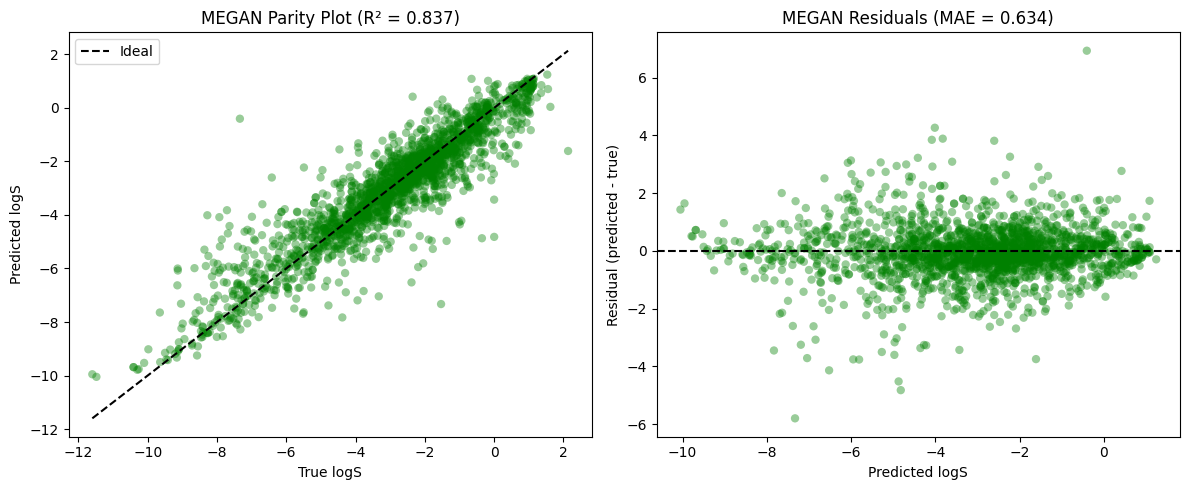

In [26]:
# --- Visualize MEGAN evaluation results ---

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Parity plot: predicted vs. true logS
axes[0].scatter(megan_y_true, megan_y_pred, alpha=0.4, edgecolor='none', color='green')
lims = [min(megan_y_true.min(), megan_y_pred.min()), max(megan_y_true.max(), megan_y_pred.max())]
axes[0].plot(lims, lims, 'k--', label='Ideal')
axes[0].set_xlabel('True logS')
axes[0].set_ylabel('Predicted logS')
axes[0].set_title(f'MEGAN Parity Plot (R² = {megan_r2:.3f})')
axes[0].legend()

# Residual plot
megan_residuals = megan_y_pred - megan_y_true
axes[1].scatter(megan_y_pred, megan_residuals, alpha=0.4, edgecolor='none', color='green')
axes[1].axhline(0, color='k', linestyle='--')
axes[1].set_xlabel('Predicted logS')
axes[1].set_ylabel('Residual (predicted - true)')
axes[1].set_title(f'MEGAN Residuals (MAE = {megan_mae:.3f})')

plt.tight_layout()
plt.show()

### Channel Fidelity (Leave-One-Out Analysis)

Good predictive accuracy alone does not guarantee that MEGAN's two explanation channels are *meaningful*. We also want them to be **faithful** &mdash; the substructures a channel highlights should genuinely drive the prediction in the direction that channel is meant to represent. MEGAN lets us verify this directly with a **leave-one-out** analysis.

The idea is simple: for each molecule we record the model's baseline prediction, then mask out one channel at a time (setting all of its attention values to zero) and re-predict. The resulting *deviation* &mdash; `baseline − masked` &mdash; measures how much that channel contributed to the output. The library exposes this through `model.leave_one_out_deviations(graphs)`, which returns one deviation value for every graph, output and channel (shape `(N, num_outputs, num_channels)`).

Aggregated over the whole test set, the deviations reveal whether the channels behave as intended:

- **Channel 0 (negative / lowers solubility):** masking it removes a *downward* push, so the prediction should *rise* &mdash; its deviations should sit **below zero**.
- **Channel 1 (positive / raises solubility):** masking it removes an *upward* push, so the prediction should *fall* &mdash; its deviations should sit **above zero**.

Following the library's convention, we summarize each channel with a *fidelity* value of `[−mean(dev₀), +mean(dev₁)]`, so that a **positive** number always means the channel moves the prediction in its intended direction. Consistently positive fidelity is concrete evidence that the explanations are causally tied to the model output rather than being decorative attention patterns.

Mean leave-one-out fidelity over 1978 test molecules:
  Channel 0 (negative / lowers solubility): +1.223
  Channel 1 (positive / raises solubility): +0.688
  (a positive value means the channel moves the prediction in its intended direction)


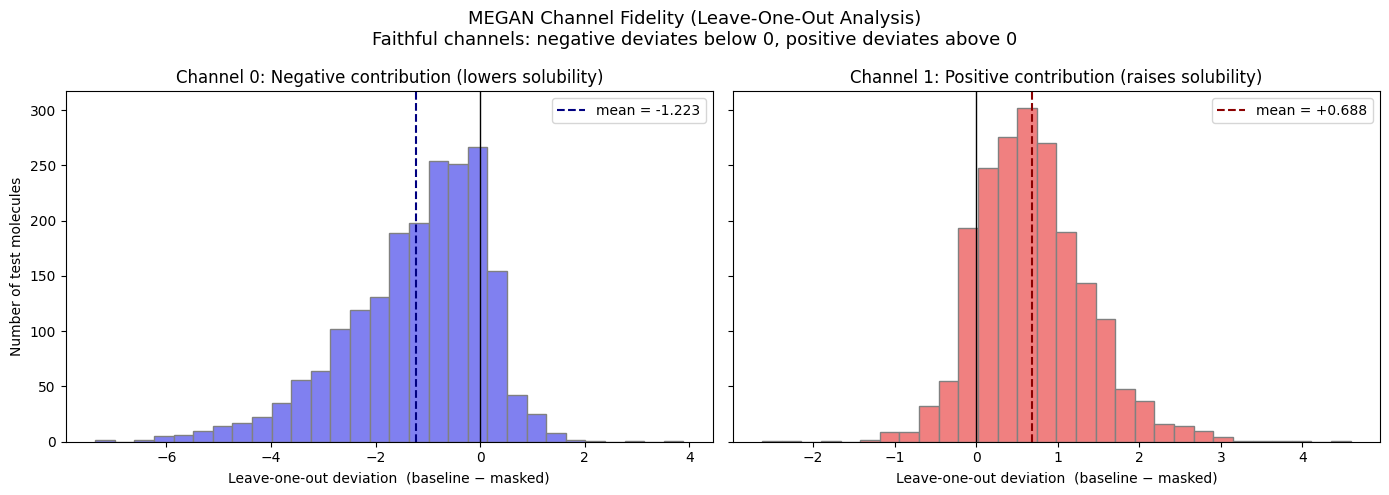

In [27]:
# --- Channel fidelity via leave-one-out analysis ---

# `leave_one_out_deviations` expects graph DICT representations (as produced by
# `graph_dict_from_smiles`), not the PyG `Data` objects used for training. We build them
# for the test molecules here.
megan_graphs_test = [
    graph_dict_from_smiles(data_frame.iloc[idx]['smiles'])
    for idx in test_indices
]

# The deviation computation calls `.numpy()` on the model output, so it must run on the
# CPU. We move the model to the CPU (the subsequent explanation cells also operate on CPU).
megan_model.cpu()

# loo_deviations: shape (num_test_molecules, num_outputs=1, num_channels=2)
# Each entry is `baseline_prediction - prediction_with_that_channel_masked`.
loo_deviations = megan_model.leave_one_out_deviations(megan_graphs_test)

# Channel 0 = negative (lowers solubility): masking it should RAISE the prediction -> dev < 0
# Channel 1 = positive (raises solubility): masking it should LOWER the prediction -> dev > 0
dev_negative = loo_deviations[:, 0, 0]
dev_positive = loo_deviations[:, 0, 1]

# Library convention: fidelity = [-mean(dev_0), +mean(dev_1)], so a POSITIVE value means the
# channel moves the prediction in its intended direction.
fidelity_negative = -float(np.mean(dev_negative))
fidelity_positive = float(np.mean(dev_positive))

print(f'Mean leave-one-out fidelity over {len(megan_graphs_test)} test molecules:')
print(f'  Channel 0 (negative / lowers solubility): {fidelity_negative:+.3f}')
print(f'  Channel 1 (positive / raises solubility): {fidelity_positive:+.3f}')
print('  (a positive value means the channel moves the prediction in its intended direction)')

# --- Visualization: per-channel deviation distributions ---
# Same color convention as the explanation plots: negative channel -> blue, positive -> red.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Channel 0 (negative contribution) -> blue. A faithful channel clusters BELOW zero.
axes[0].hist(dev_negative, bins=30, color='#8080F0', edgecolor='gray')
axes[0].axvline(0.0, color='black', linewidth=1.0)
axes[0].axvline(np.mean(dev_negative), color='navy', linestyle='dashed',
                label=f'mean = {np.mean(dev_negative):+.3f}')
axes[0].set_title('Channel 0: Negative contribution (lowers solubility)')
axes[0].set_xlabel('Leave-one-out deviation  (baseline − masked)')
axes[0].set_ylabel('Number of test molecules')
axes[0].legend()

# Channel 1 (positive contribution) -> red. A faithful channel clusters ABOVE zero.
axes[1].hist(dev_positive, bins=30, color='lightcoral', edgecolor='gray')
axes[1].axvline(0.0, color='black', linewidth=1.0)
axes[1].axvline(np.mean(dev_positive), color='darkred', linestyle='dashed',
                label=f'mean = {np.mean(dev_positive):+.3f}')
axes[1].set_title('Channel 1: Positive contribution (raises solubility)')
axes[1].set_xlabel('Leave-one-out deviation  (baseline − masked)')
axes[1].legend()

plt.suptitle('MEGAN Channel Fidelity (Leave-One-Out Analysis)\n'
             'Faithful channels: negative deviates below 0, positive deviates above 0', fontsize=13)
plt.tight_layout()
plt.show()# --- Helper functions for MEGAN explanations ---

def graph_add_megan_explanation(
    graph: nx.Graph,
    node_importance: np.ndarray,
    edge_importance: np.ndarray,
    edge_index: np.ndarray,
) -> nx.Graph:
    """
    Attaches MEGAN multi-channel explanations to a networkx graph.

    For each channel, node explanations are stored under 'node_explanation_1',
    'node_explanation_2', etc., and edge explanations under 'edge_explanation_1',
    'edge_explanation_2', etc.

    :param graph: The networkx Graph instance to attach explanations to.
    :param node_importance: Array of shape (num_nodes, num_channels) containing
        node importance values for each channel.
    :param edge_importance: Array of shape (num_edges, num_channels) containing
        edge importance values for each channel.
    :param edge_index: Array of shape (2, num_edges) containing the edge indices
        from the PyG data format (bidirectional).

    :returns: The updated graph object with channel-specific explanation attributes.
    """
    num_channels = node_importance.shape[1]

    # Attach node explanations for each channel
    for channel in range(num_channels):
        node_key = f"node_explanation_{channel + 1}"
        for node_idx in range(min(len(node_importance), len(graph.nodes()))):
            graph.nodes[node_idx][node_key] = float(node_importance[node_idx, channel])

    # For edge explanations, we need to average bidirectional edges and map to networkx edges
    for channel in range(num_channels):
        edge_key = f"edge_explanation_{channel + 1}"

        # Collect edge importance values, averaging both directions
        edge_importance_dict = {}
        for idx in range(edge_index.shape[1]):
            u, v = int(edge_index[0, idx]), int(edge_index[1, idx])
            # Use canonical ordering (min, max) as key for undirected edge
            key = (min(u, v), max(u, v))
            if key not in edge_importance_dict:
                edge_importance_dict[key] = []
            edge_importance_dict[key].append(float(edge_importance[idx, channel]))

        # Average and assign to graph edges
        for (u, v), values in edge_importance_dict.items():
            avg_value = np.mean(values)
            if graph.has_edge(u, v):
                graph.edges[(u, v)][edge_key] = avg_value
            elif graph.has_edge(v, u):
                graph.edges[(v, u)][edge_key] = avg_value

    return graph


def draw_explanation_megan(
    graph: nx.Graph,
    pos: dict,
    ax: plt.Axes,
) -> None:
    """
    Draws MEGAN multi-channel explanations on a graph visualization.

    This function calls the base `draw_explanation` function twice - once for each
    channel - using different colors to distinguish the two explanation types:
    - Channel 1 (negative contribution / lowers solubility): shown in blue (#8080F0)
    - Channel 2 (positive contribution / raises solubility): shown in red (lightcoral)

    The graph should have explanation attributes attached via `graph_add_megan_explanation`
    before calling this function.

    :param graph: The networkx graph with MEGAN explanation attributes
        (node_explanation_1, node_explanation_2, edge_explanation_1, edge_explanation_2).
    :param pos: Dictionary of node positions.
    :param ax: The matplotlib axes to draw on.
    """
    # Draw Channel 1 (negative contribution) in blue
    draw_explanation(
        graph, pos, ax,
        node_key="node_explanation_1",
        edge_key="edge_explanation_1",
        positive_color="#8080F0"
    )

    # Draw Channel 2 (positive contribution) in red
    draw_explanation(
        graph, pos, ax,
        node_key="node_explanation_2",
        edge_key="edge_explanation_2",
        positive_color="lightcoral"
    )


# --- Visualizing MEGAN multi-channel explanations ---
# MEGAN provides separate explanations for each channel. We'll visualize both channels
# side by side to show how different parts of the molecule push the predicted solubility
# down (negative channel) or up (positive channel).

# Create a fresh networkx graph for visualization
megan_graph = graph_from_smiles(SMILES)

# Attach MEGAN explanations to the graph using the helper function
graph_add_megan_explanation(
    megan_graph,
    node_importance,
    edge_importance,
    megan_batch.edge_index.numpy()
)

# Create side-by-side visualization of both channels. For regression the two channels
# separate the contributions relative to the average solubility:
# Channel 1 = negative contribution -> Blue (pushes solubility below average)
# Channel 2 = positive contribution -> Red (pushes solubility above average)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Channel 1: negative contribution
pos = draw_graph(megan_graph, axes[0])
draw_explanation(
    megan_graph, pos, axes[0],
    node_key="node_explanation_1",
    edge_key="edge_explanation_1",
    positive_color="#8080F0"
)
axes[0].set_title(
    'Channel 1: Negative contribution (lowers solubility)\n'
    f'node importance  min / median / max: '
    f'{node_importance[:, 0].min():.3f} / {np.median(node_importance[:, 0]):.3f} / {node_importance[:, 0].max():.3f}'
)
axes[0].axis('off')

# Channel 2: positive contribution
pos = draw_graph(megan_graph, axes[1])
draw_explanation(
    megan_graph, pos, axes[1],
    node_key="node_explanation_2",
    edge_key="edge_explanation_2",
    positive_color="lightcoral"
)
axes[1].set_title(
    'Channel 2: Positive contribution (raises solubility)\n'
    f'node importance  min / median / max: '
    f'{node_importance[:, 1].min():.3f} / {np.median(node_importance[:, 1]):.3f} / {node_importance[:, 1].max():.3f}'
)
axes[1].axis('off')

plt.suptitle(f'MEGAN Multi-Channel Explanations\nPredicted logS: {prediction:.3f}\n(Blue = lowers solubility, Red = raises solubility)', fontsize=14)
plt.tight_layout()
plt.show()

**Generating MEGAN Explanations.** With MEGAN, explanations are generated as part of the forward pass. The model returns not only the prediction but also the node and edge importance values for each explanation channel.

In [28]:
# --- Generating explanations with MEGAN ---
# We'll use the same molecule as in the previous examples for comparison.

from torch_geometric.data import Batch

SMILES = 'CC(=O)Cc1ccc(O)cc1'

# Convert the molecule to MEGAN format. The target value is not used during the
# forward pass / explanation, so any placeholder works here.
megan_data = megan_data_from_smiles(SMILES, target=0.0)

# IMPORTANT: MEGAN requires the `batch` attribute to be set, which indicates which graph
# each node belongs to. When passing a single Data object directly (without using DataLoader),
# this attribute is None. We use Batch.from_data_list() to properly create a batched object
# even for a single graph.
megan_batch = Batch.from_data_list([megan_data])

# Run forward pass to get prediction and explanations
with torch.no_grad():
    # MEGAN's forward method returns a dictionary with all outputs
    megan_output = megan_model.forward(megan_batch)

# Extract the results
prediction = megan_output['graph_output'].view(-1)[0].item()
node_importance = megan_output['node_importance'].numpy()  # Shape: (num_nodes, num_channels)
edge_importance = megan_output['edge_importance'].numpy()  # Shape: (num_edges, num_channels)

print(f'Molecule: {SMILES}')
print(f'Predicted logS: {prediction:.4f}')
print(f'Node importance shape: {node_importance.shape}')
print(f'Edge importance shape: {edge_importance.shape}')
print(f'\nNode importance per channel:')
print(f'  Channel 0 (negative / lowers solubility): min={node_importance[:, 0].min():.4f}, max={node_importance[:, 0].max():.4f}')
print(f'  Channel 1 (positive / raises solubility): min={node_importance[:, 1].min():.4f}, max={node_importance[:, 1].max():.4f}')

Molecule: CC(=O)Cc1ccc(O)cc1
Predicted logS: -1.2159
Node importance shape: (11, 2)
Edge importance shape: (22, 2)

Node importance per channel:
  Channel 0 (negative / lowers solubility): min=0.0718, max=0.1879
  Channel 1 (positive / raises solubility): min=0.0701, max=1.0000


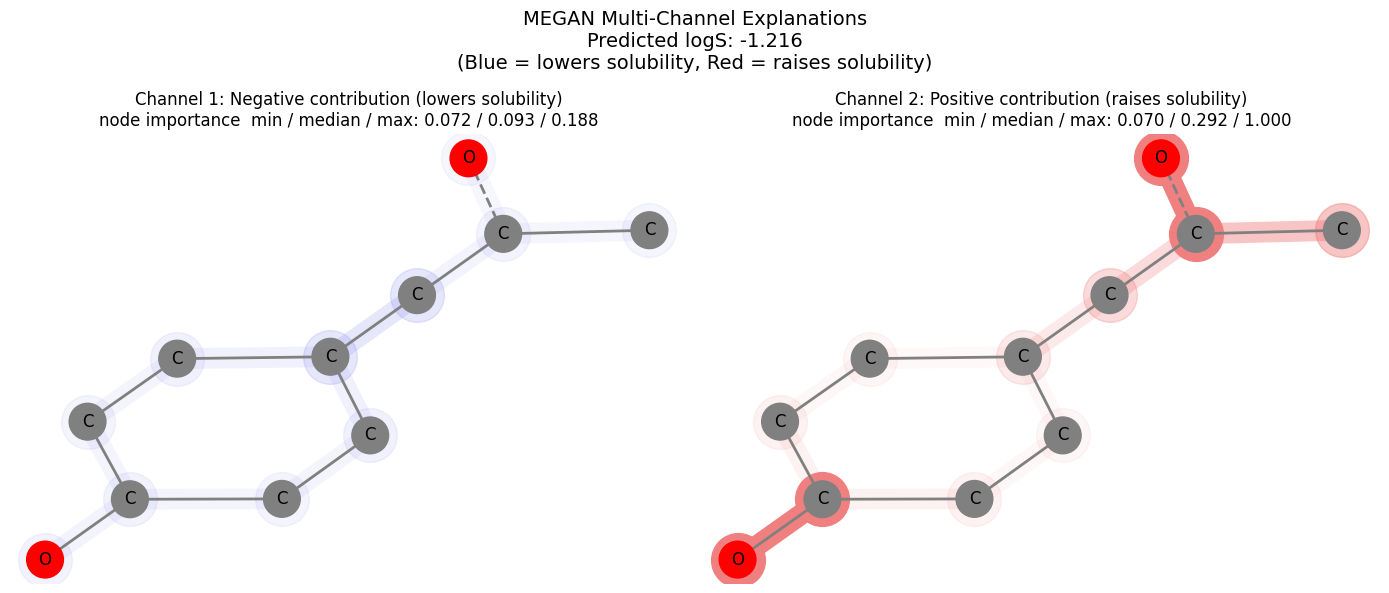

In [ ]:
# --- Helper functions for MEGAN explanations ---

def graph_add_megan_explanation(
    graph: nx.Graph,
    node_importance: np.ndarray,
    edge_importance: np.ndarray,
    edge_index: np.ndarray,
) -> nx.Graph:
    """
    Attaches MEGAN multi-channel explanations to a networkx graph.

    For each channel, node explanations are stored under 'node_explanation_1',
    'node_explanation_2', etc., and edge explanations under 'edge_explanation_1',
    'edge_explanation_2', etc.

    :param graph: The networkx Graph instance to attach explanations to.
    :param node_importance: Array of shape (num_nodes, num_channels) containing
        node importance values for each channel.
    :param edge_importance: Array of shape (num_edges, num_channels) containing
        edge importance values for each channel.
    :param edge_index: Array of shape (2, num_edges) containing the edge indices
        from the PyG data format (bidirectional).

    :returns: The updated graph object with channel-specific explanation attributes.
    """
    num_channels = node_importance.shape[1]

    # Attach node explanations for each channel
    for channel in range(num_channels):
        node_key = f"node_explanation_{channel + 1}"
        for node_idx in range(min(len(node_importance), len(graph.nodes()))):
            graph.nodes[node_idx][node_key] = float(node_importance[node_idx, channel])

    # For edge explanations, we need to average bidirectional edges and map to networkx edges
    for channel in range(num_channels):
        edge_key = f"edge_explanation_{channel + 1}"

        # Collect edge importance values, averaging both directions
        edge_importance_dict = {}
        for idx in range(edge_index.shape[1]):
            u, v = int(edge_index[0, idx]), int(edge_index[1, idx])
            # Use canonical ordering (min, max) as key for undirected edge
            key = (min(u, v), max(u, v))
            if key not in edge_importance_dict:
                edge_importance_dict[key] = []
            edge_importance_dict[key].append(float(edge_importance[idx, channel]))

        # Average and assign to graph edges
        for (u, v), values in edge_importance_dict.items():
            avg_value = np.mean(values)
            if graph.has_edge(u, v):
                graph.edges[(u, v)][edge_key] = avg_value
            elif graph.has_edge(v, u):
                graph.edges[(v, u)][edge_key] = avg_value

    return graph


def draw_explanation_megan(
    graph: nx.Graph,
    pos: dict,
    ax: plt.Axes,
) -> None:
    """
    Draws MEGAN multi-channel explanations on a graph visualization.

    This function calls the base `draw_explanation` function twice - once for each
    channel - using different colors to distinguish the two explanation types:
    - Channel 1 (negative contribution / lowers solubility): shown in blue (#8080F0)
    - Channel 2 (positive contribution / raises solubility): shown in red (lightcoral)

    The graph should have explanation attributes attached via `graph_add_megan_explanation`
    before calling this function.

    :param graph: The networkx graph with MEGAN explanation attributes
        (node_explanation_1, node_explanation_2, edge_explanation_1, edge_explanation_2).
    :param pos: Dictionary of node positions.
    :param ax: The matplotlib axes to draw on.
    """
    # Draw Channel 1 (negative contribution) in blue
    draw_explanation(
        graph, pos, ax,
        node_key="node_explanation_1",
        edge_key="edge_explanation_1",
        positive_color="#8080F0"
    )

    # Draw Channel 2 (positive contribution) in red
    draw_explanation(
        graph, pos, ax,
        node_key="node_explanation_2",
        edge_key="edge_explanation_2",
        positive_color="lightcoral"
    )


# --- Visualizing MEGAN multi-channel explanations ---
# MEGAN provides separate explanations for each channel. We'll visualize both channels
# side by side to show how different parts of the molecule push the predicted solubility
# down (negative channel) or up (positive channel).

# Create a fresh networkx graph for visualization
megan_graph = graph_from_smiles(SMILES)

# Attach MEGAN explanations to the graph using the helper function
graph_add_megan_explanation(
    megan_graph,
    node_importance,
    edge_importance,
    megan_batch.edge_index.numpy()
)

# Create side-by-side visualization of both channels. For regression the two channels
# separate the contributions relative to the average solubility:
# Channel 1 = negative contribution -> Blue (pushes solubility below average)
# Channel 2 = positive contribution -> Red (pushes solubility above average)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Channel 1: negative contribution
pos = draw_graph(megan_graph, axes[0])
draw_explanation(
    megan_graph, pos, axes[0],
    node_key="node_explanation_1",
    edge_key="edge_explanation_1",
    positive_color="#8080F0"
)
axes[0].set_title(
    'Channel 1: Negative contribution (lowers solubility)\n'
    f'node importance  min / median / max: '
    f'{node_importance[:, 0].min():.3f} / {np.median(node_importance[:, 0]):.3f} / {node_importance[:, 0].max():.3f}'
)
axes[0].axis('off')

# Channel 2: positive contribution
pos = draw_graph(megan_graph, axes[1])
draw_explanation(
    megan_graph, pos, axes[1],
    node_key="node_explanation_2",
    edge_key="edge_explanation_2",
    positive_color="lightcoral"
)
axes[1].set_title(
    'Channel 2: Positive contribution (raises solubility)\n'
    f'node importance  min / median / max: '
    f'{node_importance[:, 1].min():.3f} / {np.median(node_importance[:, 1]):.3f} / {node_importance[:, 1].max():.3f}'
)
axes[1].axis('off')

plt.suptitle(f'MEGAN Multi-Channel Explanations\nPredicted logS: {prediction:.3f}\n(Blue = lowers solubility, Red = raises solubility)', fontsize=14)
plt.tight_layout()
plt.show()

**Interpreting MEGAN Explanations.** The visualization above demonstrates MEGAN's key advantage: the ability to provide **multi-channel explanations** that separately highlight different types of contributions to the prediction. For a regression task like solubility prediction, the two channels separate contributions relative to the average (reference) solubility:

- **Channel 0 (Negative contribution)**: Highlights substructures that push the predicted solubility *below* the reference value &mdash; typically large hydrophobic or aromatic regions that make a molecule less water-soluble.

- **Channel 1 (Positive contribution)**: Highlights substructures that push the predicted solubility *above* the reference value &mdash; typically polar groups such as hydroxyl, amine or carbonyl moieties that form favorable interactions with water.

**Key Differences from Post-hoc Methods.** Unlike GNNExplainer, which explains a *fixed* pre-trained model, MEGAN's explanations are an integral part of the model itself. This has important implications:

1. **Consistency**: The explanations are always consistent with the predictions because they use the same attention weights that determine how information flows through the network.

2. **Efficiency**: No additional computation is required to generate explanations &mdash; they come "for free" with each prediction.

3. **Trainability**: MEGAN can be trained with *explanation co-training* by setting `importance_factor > 0` (as we do here). For regression this self-supervised objective encourages the negative and positive channels to specialize on the substructures that respectively lower and raise the predicted value, improving the quality and separation of the two channels.

4. **Channel Interpretability**: The multi-channel structure provides richer information than single-channel explanations, allowing domain experts to understand not just *what* is important but *how* different structural features contribute in opposing directions.

**📝 Note.** The interpretation of channels depends on the task. For regression (as here), the channels separate negative and positive contributions to the predicted value relative to the `regression_reference`. For classification tasks each channel would instead correspond to one class. The `sparsity_factor` parameter controls how focused the explanations are &mdash; higher values produce sparser, more localized explanations at the cost of potentially missing some contributing substructures.

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 2.4** $\cdot$ MEGAN's `importance_offset` parameter controls how *expansive* the learned explanations are: larger values push the model towards highlighting more atoms, while smaller values yield more focused, sparse explanations.

Retrain the MEGAN model with the offset shifted by &plusmn;0.5 around its default of `1.0`:
1. `importance_offset=0.5` (more focused explanations)
2. `importance_offset=1.0` (the default used above)
3. `importance_offset=1.5` (more expansive explanations)

For each setting, regenerate the explanations for an amphiphilic molecule such as `'OCCCCCCCCCCCC'` (dodecanol &mdash; a polar hydroxyl head on a long hydrophobic tail) and compare how many atoms each channel highlights. How does the offset affect: (1) whether the hydroxyl group is cleanly isolated in the positive channel and the alkyl chain in the negative channel, and (2) the model's predictive performance (R²)? Is there a trade-off between how focused the explanations are and predictive accuracy?
</div>

## **2.5** $\cdot$ 🔬 Comparison of Explanation Methods

Having explored three different structure-attribution methods, we can compare their explanations side-by-side on the same molecules. This comparison helps illustrate the different perspectives each method provides and highlights their advantages and disadvantages.

**Methods Compared:**
- **GNNExplainer**: Perturbation-based method that learns a continuous *soft* mask of atom/bond importance.
- **ZORRO**: Greedy search for a *hard* (binary) set of atoms that is sufficient to preserve the prediction. Shown directionally: atoms that support solubility (red, `direction='down'`) and atoms that limit it (blue, `direction='up'`).
- **MEGAN**: Self-explaining attention network with two channels - positive contribution (red, raises solubility) and negative contribution (blue, lowers solubility).

**📝 Note.** GNNExplainer and ZORRO both explain our `SimpleRegressor` model, while MEGAN is a separate model. Differences between the panels therefore reflect both the explanation method and differences in how the underlying models learned to make predictions.

In [34]:
# --- Helper function to generate all explanations for a molecule ---

from torch_geometric.explain.algorithm.utils import clear_masks

def generate_all_explanations(smiles: str,
                               target: float,
                               gnn_model: SimpleGNNModel,
                               gnn_explainer: Explainer,
                               megan_model: Megan,
                               ) -> dict:
    """
    Generate explanations from all methods for a given molecule.

    All computations are done on CPU to avoid device mismatch issues.

    If any method fails, it will print the error and return zeros for that method's
    explanations, allowing the comparison to continue with the other methods.

    :param smiles: SMILES string of the molecule
    :param target: The continuous (true) regression target value (logS)
    :param gnn_model: The trained SimpleGNNModel (native torch module)
    :param gnn_explainer: The GNNExplainer instance
    :param megan_model: The trained MEGAN model
    :returns: Dictionary containing explanations from all methods
    """
    results = {'smiles': smiles, 'target': target}

    # Move all models to CPU for consistent evaluation
    device = torch.device('cpu')
    gnn_model = gnn_model.to(device)
    gnn_model.eval()

    # Move the explainer algorithm AND its model reference to CPU
    gnn_explainer.algorithm = gnn_explainer.algorithm.to(device)
    gnn_explainer.model = gnn_explainer.model.to(device)

    # --- Prepare data (used by multiple methods) ---
    graph = graph_from_smiles(smiles)
    graph.graph['graph_labels'] = [target]
    data = data_from_graph(graph)
    num_nodes = data.x.shape[0]
    num_edges = data.edge_index.shape[1]

    # Store edge_index for later use in visualization
    results['edge_index'] = data.edge_index.numpy().copy()

    # Create batch on CPU
    loader = DataLoader([data], batch_size=1, shuffle=False)
    batch = next(iter(loader))  # Already on CPU

    # --- GNN Prediction (raw predicted logS) ---
    try:
        with torch.no_grad():
            output = gnn_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            gnn_pred = output.view(-1)[0].item()
        results['gnn_prediction'] = gnn_pred
    except Exception as e:
        print(f"    [GNN Prediction] Error: {e}")
        results['gnn_prediction'] = 0.0

    # --- GNNExplainer ---
    try:
        # Clean up model masks
        clear_masks(gnn_model)
        clear_masks(gnn_explainer.model)

        # Reset GNNExplainer's internal mask state to avoid size mismatches
        # from previous molecules that may have failed partway through
        gnn_explainer.algorithm.node_mask = None
        gnn_explainer.algorithm.hard_node_mask = None
        gnn_explainer.algorithm.edge_mask = None
        gnn_explainer.algorithm.hard_edge_mask = None

        # explanation_type='model' -> the target is inferred from the model's own
        # prediction, so we do not pass a target here.
        explanation = gnn_explainer(
            x=batch.x,
            edge_index=batch.edge_index,
            edge_attr=batch.edge_attr,
            batch=batch.batch,
            index=0
        )
        results['gnnexplainer_node'] = explanation.node_mask.detach().numpy()
        if explanation.edge_mask is not None:
            results['gnnexplainer_edge'] = explanation.edge_mask.detach().numpy()
        else:
            results['gnnexplainer_edge'] = None
    except Exception as e:
        print(f"    [GNNExplainer] Error: {e}")
        results['gnnexplainer_node'] = np.zeros(num_nodes)
        results['gnnexplainer_edge'] = None
    finally:
        # Always clean up, even on error
        clear_masks(gnn_model)
        clear_masks(gnn_explainer.model)
        gnn_explainer.algorithm.node_mask = None
        gnn_explainer.algorithm.hard_node_mask = None
        gnn_explainer.algorithm.edge_mask = None
        gnn_explainer.algorithm.hard_edge_mask = None

    # --- MEGAN ---
    try:
        # Move MEGAN to CPU as well
        megan_model = megan_model.to(device)
        megan_model.eval()

        megan_data = megan_data_from_smiles(smiles, target)
        megan_batch = Batch.from_data_list([megan_data])  # Already on CPU

        with torch.no_grad():
            megan_output = megan_model.forward(megan_batch)

        megan_pred = megan_output['graph_output'].view(-1)[0].item()
        results['megan_prediction'] = megan_pred

        results['megan_node_ch0'] = megan_output['node_importance'][:, 0].numpy()
        results['megan_node_ch1'] = megan_output['node_importance'][:, 1].numpy()
        results['megan_edge_ch0'] = megan_output['edge_importance'][:, 0].numpy()
        results['megan_edge_ch1'] = megan_output['edge_importance'][:, 1].numpy()
        results['megan_edge_index'] = megan_batch.edge_index.numpy()
    except Exception as e:
        print(f"    [MEGAN] Error: {e}")
        results['megan_prediction'] = 0.0
        results['megan_node_ch0'] = np.zeros(num_nodes)
        results['megan_node_ch1'] = np.zeros(num_nodes)
        results['megan_edge_ch0'] = None
        results['megan_edge_ch1'] = None
        results['megan_edge_index'] = None

    # --- ZORRO (directional hard masks) ---
    # Use the SAME settings as the standalone ZORRO section. A wider tolerance band (or a
    # lower fidelity threshold) can let the EMPTY atom set already satisfy the threshold, in
    # which case the greedy search stops without selecting any atoms -> an all-zero (blank)
    # mask. tolerance=0.3 / fidelity_threshold=0.9 forces a non-trivial selection.
    try:
        # 'down' -> atoms that keep the prediction from falling (support solubility)
        zr_down, fid_down = zorro_explain(smiles, gnn_model, direction='down', tolerance=0.3, fidelity_threshold=0.95, samples=200)
        # 'up'   -> atoms that keep the prediction from rising (limit solubility)
        zr_up, fid_up = zorro_explain(smiles, gnn_model, direction='up', tolerance=0.3, fidelity_threshold=0.95, samples=200)
        results['zorro_node_down'] = zr_down
        results['zorro_node_up'] = zr_up
        print(f"    [ZORRO] down: {int(np.sum(zr_down))} atoms (fidelity {fid_down:.2f})  |  up: {int(np.sum(zr_up))} atoms (fidelity {fid_up:.2f})")
    except Exception:
        # Surface the full traceback instead of swallowing it, so a genuine failure is not
        # silently hidden behind an all-zero (blank) explanation.
        import traceback
        print("    [ZORRO] Error:")
        traceback.print_exc()
        results['zorro_node_down'] = np.zeros(num_nodes)
        results['zorro_node_up'] = np.zeros(num_nodes)

    # Final cleanup
    clear_masks(gnn_model)
    clear_masks(gnn_explainer.model)

    return results

In [35]:
# --- Shared utility: cast explanations between nodes and edges ---
# This helper derives the missing explanation type (node or edge) for methods
# that only provide one of the two. It is used by the comparison visualization
# below to fill in node/edge explanations for each MEGAN channel.

def cast_explanations(
    g: nx.Graph,
    node_key: str = "node_explanation",
    edge_key: str = "edge_explanation",
    aggregation: str = 'mean',
) -> nx.Graph:
    """
    Casts explanation attributes between nodes and edges of a graph.

    If the graph has only node explanations (under `node_key`), this function computes
    edge explanations by aggregating the explanation values of incident nodes for each
    edge. Conversely, if the graph has only edge explanations (under `edge_key`), it
    computes node explanations by aggregating the explanation values of all adjacent
    edges for each node.

    If the graph has both node and edge explanations, or neither, the graph is returned
    unchanged.

    :param g: A networkx Graph object that may contain explanation attributes
        on its nodes and/or edges.
    :param node_key: The key used to store/retrieve node explanation values.
        Default is "node_explanation".
    :param edge_key: The key used to store/retrieve edge explanation values.
        Default is "edge_explanation".
    :param aggregation: The aggregation method to use when combining explanation values.
        Supported values are 'mean', 'max', 'min', and 'sum'. Default is 'mean'.

    :returns: The same graph object with potentially added explanation attributes.
        The graph is modified in-place.
    """

    # Dictionary mapping aggregation names to numpy functions.
    # This provides a simple way to select the aggregation method without
    # needing external helper functions.
    aggregation_functions = {
        'mean': np.mean,
        'max': np.max,
        'min': np.min,
        'sum': np.sum,
    }

    if aggregation not in aggregation_functions:
        raise ValueError(
            f"Unknown aggregation method: '{aggregation}'. "
            f"Supported methods are: {list(aggregation_functions.keys())}"
        )

    agg_fn = aggregation_functions[aggregation]

    # --- Check which explanation types are present ---
    # We check the first node/edge to determine if explanations exist.
    # We assume that if one node/edge has explanations, all of them do.

    has_node_explanations = False
    has_edge_explanations = False

    # Check for node explanations by inspecting the first node
    if len(g.nodes()) > 0:
        first_node_data = next(iter(g.nodes(data=True)))[1]
        has_node_explanations = node_key in first_node_data

    # Check for edge explanations by inspecting the first edge
    if len(g.edges()) > 0:
        first_edge_data = next(iter(g.edges(data=True)))[2]
        has_edge_explanations = edge_key in first_edge_data

    # --- Handle the different cases ---
    # If both or neither explanation types are present, return unchanged

    if has_node_explanations == has_edge_explanations:
        # Either both are True (has both) or both are False (has neither)
        return g

    if has_node_explanations and not has_edge_explanations:
        # Cast node explanations to edge explanations.
        # For each edge, aggregate the explanation values of its two incident nodes.

        for (u, v) in g.edges():
            node_u_explanation = g.nodes[u][node_key]
            node_v_explanation = g.nodes[v][node_key]

            # Aggregate the two node values to get the edge explanation
            edge_explanation = agg_fn([node_u_explanation, node_v_explanation])
            g.edges[(u, v)][edge_key] = float(edge_explanation)

    elif has_edge_explanations and not has_node_explanations:
        # Cast edge explanations to node explanations.
        # For each node, aggregate the explanation values of all adjacent edges.

        for node in g.nodes():
            # Collect explanation values from all edges connected to this node
            adjacent_edge_explanations = []

            for neighbor in g.neighbors(node):
                # NetworkX stores undirected edges once, so we need to check
                # which ordering exists in the graph
                if g.has_edge(node, neighbor):
                    edge_exp = g.edges[(node, neighbor)][edge_key]
                else:
                    edge_exp = g.edges[(neighbor, node)][edge_key]

                adjacent_edge_explanations.append(edge_exp)

            # Aggregate the adjacent edge values to get the node explanation
            if len(adjacent_edge_explanations) > 0:
                node_explanation = agg_fn(adjacent_edge_explanations)
            else:
                # Isolated node with no adjacent edges - assign zero
                node_explanation = 0.0

            g.nodes[node][node_key] = float(node_explanation)

    return g# --- Visualization function for side-by-side comparison ---

def graph_add_node_explanations(
    graph: nx.Graph,
    node_values: np.ndarray,
    node_key: str = "node_explanation",
) -> nx.Graph:
    """
    Attaches node explanation values from a numpy array to a networkx graph.

    :param graph: The networkx Graph instance.
    :param node_values: Array of shape (num_nodes,) containing explanation values.
    :param node_key: The key to use for storing node explanations.
    :returns: The updated graph object.
    """
    for node_idx in range(min(len(node_values), len(graph.nodes()))):
        graph.nodes[node_idx][node_key] = float(node_values[node_idx])
    return graph


def graph_add_edge_explanations(
    graph: nx.Graph,
    edge_values: np.ndarray,
    edge_index: np.ndarray,
    edge_key: str = "edge_explanation",
) -> nx.Graph:
    """
    Attaches edge explanation values from a numpy array to a networkx graph.

    Handles the mapping from PyG bidirectional edge indices to networkx undirected edges
    by averaging the values from both directions.

    :param graph: The networkx Graph instance.
    :param edge_values: Array of shape (num_edges,) containing explanation values.
    :param edge_index: Array of shape (2, num_edges) containing edge indices.
    :param edge_key: The key to use for storing edge explanations.
    :returns: The updated graph object.
    """
    # Collect edge values, averaging both directions for undirected edges
    edge_value_dict = {}
    for idx in range(edge_index.shape[1]):
        u, v = int(edge_index[0, idx]), int(edge_index[1, idx])
        key = (min(u, v), max(u, v))  # Canonical ordering
        if key not in edge_value_dict:
            edge_value_dict[key] = []
        edge_value_dict[key].append(float(edge_values[idx]))

    # Average and assign to graph edges
    for (u, v), values in edge_value_dict.items():
        avg_value = np.mean(values)
        if graph.has_edge(u, v):
            graph.edges[(u, v)][edge_key] = avg_value
        elif graph.has_edge(v, u):
            graph.edges[(v, u)][edge_key] = avg_value

    return graph


def plot_explanation_comparison(smiles: str,
                                 explanations: dict,
                                 figsize: tuple = (10, 5),
                                 aggregation: str = 'mean') -> None:
    """
    Create a side-by-side comparison of explanations from different methods.

    Uses networkx graphs and the `cast_explanations` function to derive missing
    explanation types (node or edge) when a method only provides one.

    ZORRO is shown directionally (red = supports solubility, blue = limits it) and
    MEGAN's two channels are shown the same way (red = raises, blue = lowers solubility).

    :param smiles: SMILES string of the molecule
    :param explanations: Dictionary containing explanations from all methods
    :param figsize: Figure size tuple
    :param aggregation: Aggregation function for deriving missing explanations
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # Method configurations
    methods = [
        {
            'name': 'GNNExplainer',
            'node_key_src': 'gnnexplainer_node',
            'edge_key_src': 'gnnexplainer_edge',
            'edge_index_key': 'edge_index',
            'color': 'lightgreen',
            'use_absolute': False,
        },
        {
            'name': 'ZORRO',
            'is_zorro': True,
        },
        {
            'name': 'MEGAN',
            'is_megan': True,
        },
    ]

    for ax, method in zip(axes, methods):

        # Create a fresh graph for each method
        graph = graph_from_smiles(smiles)

        if method.get('is_zorro', False):
            # --- ZORRO: two directional hard masks (down=red, up=blue) ---
            zr_down = explanations.get('zorro_node_down')
            zr_up = explanations.get('zorro_node_up')
            pos = draw_graph(graph, ax)
            if zr_down is not None:
                for n in range(min(len(zr_down), graph.number_of_nodes())):
                    graph.nodes[n]['zorro_down'] = float(zr_down[n])
                draw_explanation(graph, pos, ax, node_key='zorro_down', edge_key='__none__', positive_color='lightcoral')
            if zr_up is not None:
                for n in range(min(len(zr_up), graph.number_of_nodes())):
                    graph.nodes[n]['zorro_up'] = float(zr_up[n])
                draw_explanation(graph, pos, ax, node_key='zorro_up', edge_key='__none__', positive_color='#8080F0')
            node_provided = zr_down is not None
            edge_provided = False

        elif method.get('is_megan', False):
            # --- MEGAN: Handle multi-channel explanations ---
            node_ch0 = explanations.get('megan_node_ch0')
            node_ch1 = explanations.get('megan_node_ch1')
            edge_ch0 = explanations.get('megan_edge_ch0')
            edge_ch1 = explanations.get('megan_edge_ch1')
            megan_edge_index = explanations.get('megan_edge_index')

            # Attach channel 1 (negative contribution)
            if node_ch0 is not None:
                graph_add_node_explanations(graph, node_ch0, "node_explanation_1")
            if edge_ch0 is not None and megan_edge_index is not None:
                graph_add_edge_explanations(graph, edge_ch0, megan_edge_index, "edge_explanation_1")

            # Attach channel 2 (positive contribution)
            if node_ch1 is not None:
                graph_add_node_explanations(graph, node_ch1, "node_explanation_2")
            if edge_ch1 is not None and megan_edge_index is not None:
                graph_add_edge_explanations(graph, edge_ch1, megan_edge_index, "edge_explanation_2")

            # Cast missing explanations for each channel
            cast_explanations(graph, "node_explanation_1", "edge_explanation_1", aggregation)
            cast_explanations(graph, "node_explanation_2", "edge_explanation_2", aggregation)

            # Draw the graph and MEGAN explanations
            pos = draw_graph(graph, ax)
            draw_explanation_megan(graph, pos, ax)

            node_provided = node_ch0 is not None
            edge_provided = edge_ch0 is not None

        else:
            # --- Standard single-channel methods ---
            node_values = explanations.get(method['node_key_src'])
            edge_values = explanations.get(method['edge_key_src'])
            edge_index = explanations.get(method['edge_index_key'])

            # Apply absolute value if needed
            if method.get('use_absolute', False):
                if node_values is not None:
                    node_values = np.abs(node_values)
                if edge_values is not None:
                    edge_values = np.abs(edge_values)

            # Attach explanations to graph
            if node_values is not None:
                graph_add_node_explanations(graph, node_values)
            if edge_values is not None and edge_index is not None:
                graph_add_edge_explanations(graph, edge_values, edge_index)

            # Cast missing explanations
            cast_explanations(graph, aggregation=aggregation)

            # Draw the graph and explanations
            pos = draw_graph(graph, ax)
            draw_explanation(graph, pos, ax, positive_color=method['color'])

            node_provided = node_values is not None
            edge_provided = edge_values is not None

        # Add indicator showing what was provided vs derived
        node_indicator = "N" if node_provided else "n"
        edge_indicator = "E" if edge_provided else "e"
        indicator = f" ({node_indicator}+{edge_indicator})"
        ax.set_title(method['name'] + indicator, fontsize=12)
        ax.axis('off')

    # Add overall title with predictions (all values are logS)
    title = f"Molecule: {smiles}\n"
    title += f"True logS: {explanations['target']:.2f} | "
    title += f"GNN Pred: {explanations['gnn_prediction']:.2f} | "
    title += f"MEGAN Pred: {explanations['megan_prediction']:.2f}"
    fig.suptitle(title, fontsize=14, y=1.02)

    plt.tight_layout()
    plt.show()

In [38]:
# --- Visualization function for side-by-side comparison ---

def graph_add_node_explanations(
    graph: nx.Graph,
    node_values: np.ndarray,
    node_key: str = "node_explanation",
) -> nx.Graph:
    """
    Attaches node explanation values from a numpy array to a networkx graph.

    :param graph: The networkx Graph instance.
    :param node_values: Array of shape (num_nodes,) containing explanation values.
    :param node_key: The key to use for storing node explanations.
    :returns: The updated graph object.
    """
    for node_idx in range(min(len(node_values), len(graph.nodes()))):
        graph.nodes[node_idx][node_key] = float(node_values[node_idx])
    return graph


def graph_add_edge_explanations(
    graph: nx.Graph,
    edge_values: np.ndarray,
    edge_index: np.ndarray,
    edge_key: str = "edge_explanation",
) -> nx.Graph:
    """
    Attaches edge explanation values from a numpy array to a networkx graph.

    Handles the mapping from PyG bidirectional edge indices to networkx undirected edges
    by averaging the values from both directions.

    :param graph: The networkx Graph instance.
    :param edge_values: Array of shape (num_edges,) containing explanation values.
    :param edge_index: Array of shape (2, num_edges) containing edge indices.
    :param edge_key: The key to use for storing edge explanations.
    :returns: The updated graph object.
    """
    # Collect edge values, averaging both directions for undirected edges
    edge_value_dict = {}
    for idx in range(edge_index.shape[1]):
        u, v = int(edge_index[0, idx]), int(edge_index[1, idx])
        key = (min(u, v), max(u, v))  # Canonical ordering
        if key not in edge_value_dict:
            edge_value_dict[key] = []
        edge_value_dict[key].append(float(edge_values[idx]))

    # Average and assign to graph edges
    for (u, v), values in edge_value_dict.items():
        avg_value = np.mean(values)
        if graph.has_edge(u, v):
            graph.edges[(u, v)][edge_key] = avg_value
        elif graph.has_edge(v, u):
            graph.edges[(v, u)][edge_key] = avg_value

    return graph


def plot_explanation_comparison(smiles: str,
                                 explanations: dict,
                                 figsize: tuple = (10, 5),
                                 aggregation: str = 'mean') -> None:
    """
    Create a side-by-side comparison of explanations from different methods.

    Uses networkx graphs and the `cast_explanations` function to derive missing
    explanation types (node or edge) when a method only provides one.

    ZORRO is shown directionally (red = supports solubility, blue = limits it) and
    MEGAN's two channels are shown the same way (red = raises, blue = lowers solubility).

    :param smiles: SMILES string of the molecule
    :param explanations: Dictionary containing explanations from all methods
    :param figsize: Figure size tuple
    :param aggregation: Aggregation function for deriving missing explanations
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # Method configurations
    methods = [
        {
            'name': 'GNNExplainer',
            'node_key_src': 'gnnexplainer_node',
            'edge_key_src': 'gnnexplainer_edge',
            'edge_index_key': 'edge_index',
            'color': 'lightgreen',
            'use_absolute': False,
        },
        {
            'name': 'ZORRO',
            'is_zorro': True,
        },
        {
            'name': 'MEGAN',
            'is_megan': True,
        },
    ]

    for ax, method in zip(axes, methods):

        # Create a fresh graph for each method
        graph = graph_from_smiles(smiles)

        if method.get('is_zorro', False):
            # --- ZORRO: two directional hard masks (down=red, up=blue) ---
            zr_down = explanations.get('zorro_node_down')
            zr_up = explanations.get('zorro_node_up')
            pos = draw_graph(graph, ax)
            if zr_down is not None:
                for n in range(min(len(zr_down), graph.number_of_nodes())):
                    graph.nodes[n]['zorro_down'] = float(zr_down[n])
                draw_explanation(graph, pos, ax, node_key='zorro_down', edge_key='__none__', positive_color='lightcoral')
            if zr_up is not None:
                for n in range(min(len(zr_up), graph.number_of_nodes())):
                    graph.nodes[n]['zorro_up'] = float(zr_up[n])
                draw_explanation(graph, pos, ax, node_key='zorro_up', edge_key='__none__', positive_color='#8080F0')
            node_provided = zr_down is not None
            edge_provided = False

        elif method.get('is_megan', False):
            # --- MEGAN: Handle multi-channel explanations ---
            node_ch0 = explanations.get('megan_node_ch0')
            node_ch1 = explanations.get('megan_node_ch1')
            edge_ch0 = explanations.get('megan_edge_ch0')
            edge_ch1 = explanations.get('megan_edge_ch1')
            megan_edge_index = explanations.get('megan_edge_index')

            # Attach channel 1 (negative contribution)
            if node_ch0 is not None:
                graph_add_node_explanations(graph, node_ch0, "node_explanation_1")
            if edge_ch0 is not None and megan_edge_index is not None:
                graph_add_edge_explanations(graph, edge_ch0, megan_edge_index, "edge_explanation_1")

            # Attach channel 2 (positive contribution)
            if node_ch1 is not None:
                graph_add_node_explanations(graph, node_ch1, "node_explanation_2")
            if edge_ch1 is not None and megan_edge_index is not None:
                graph_add_edge_explanations(graph, edge_ch1, megan_edge_index, "edge_explanation_2")

            # Cast missing explanations for each channel
            cast_explanations(graph, "node_explanation_1", "edge_explanation_1", aggregation)
            cast_explanations(graph, "node_explanation_2", "edge_explanation_2", aggregation)

            # Draw the graph and MEGAN explanations
            pos = draw_graph(graph, ax)
            draw_explanation_megan(graph, pos, ax)

            node_provided = node_ch0 is not None
            edge_provided = edge_ch0 is not None

        else:
            # --- Standard single-channel methods ---
            node_values = explanations.get(method['node_key_src'])
            edge_values = explanations.get(method['edge_key_src'])
            edge_index = explanations.get(method['edge_index_key'])

            # Apply absolute value if needed
            if method.get('use_absolute', False):
                if node_values is not None:
                    node_values = np.abs(node_values)
                if edge_values is not None:
                    edge_values = np.abs(edge_values)

            # Attach explanations to graph
            if node_values is not None:
                graph_add_node_explanations(graph, node_values)
            if edge_values is not None and edge_index is not None:
                graph_add_edge_explanations(graph, edge_values, edge_index)

            # Cast missing explanations
            cast_explanations(graph, aggregation=aggregation)

            # Draw the graph and explanations
            pos = draw_graph(graph, ax)
            draw_explanation(graph, pos, ax, positive_color=method['color'])

            node_provided = node_values is not None
            edge_provided = edge_values is not None

        # Add indicator showing what was provided vs derived
        node_indicator = "N" if node_provided else "n"
        edge_indicator = "E" if edge_provided else "e"
        indicator = f" ({node_indicator}+{edge_indicator})"
        ax.set_title(method['name'] + indicator, fontsize=12)
        ax.axis('off')

    # Add overall title with predictions (all values are logS)
    title = f"Molecule: {smiles}\n"
    title += f"True logS: {explanations['target']:.2f} | "
    title += f"GNN Pred: {explanations['gnn_prediction']:.2f} | "
    title += f"MEGAN Pred: {explanations['megan_prediction']:.2f}"
    fig.suptitle(title, fontsize=14, y=1.02)

    plt.tight_layout()
    plt.show()

Generating explanations for comparison molecules...

Processing molecule 1/4: Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(Cl)c2Cl 


/tmp/ipykernel_519009/19779303.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  graph.nodes[node_idx][node_key] = float(node_values[node_idx])


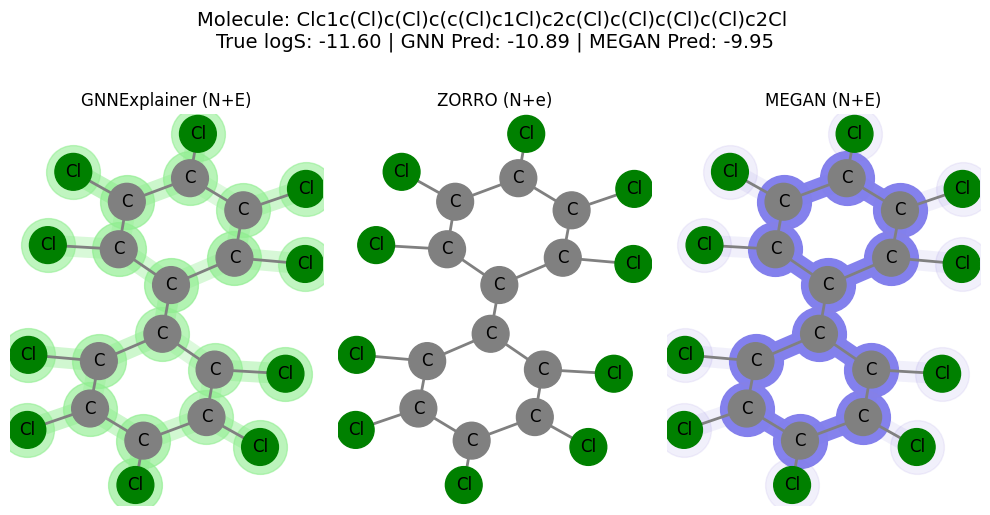

Processing molecule 2/4: O=C(O)C1=CN(C2CC2)C2=C(C=C(F)C(N3CC4CC3CN4)=C2)C1=O


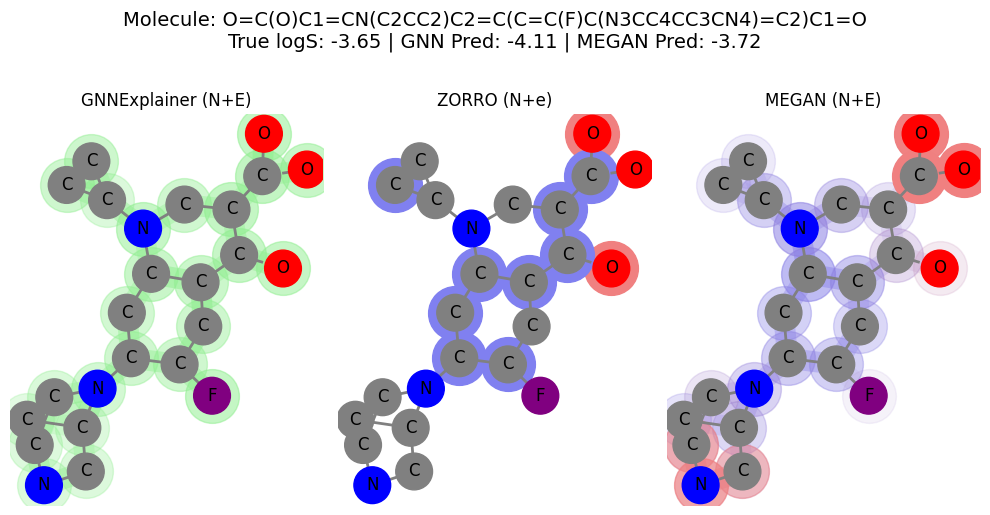

Processing molecule 3/4: COc1ccc(NC(=O)CC(C)=O)cc1


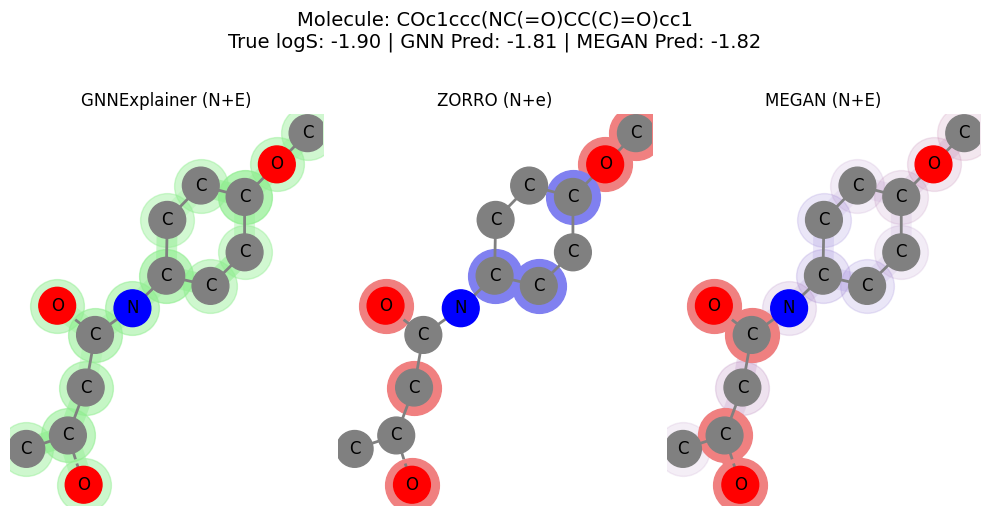

Processing molecule 4/4: CC(C)CC1CC(C)(O)CCO1


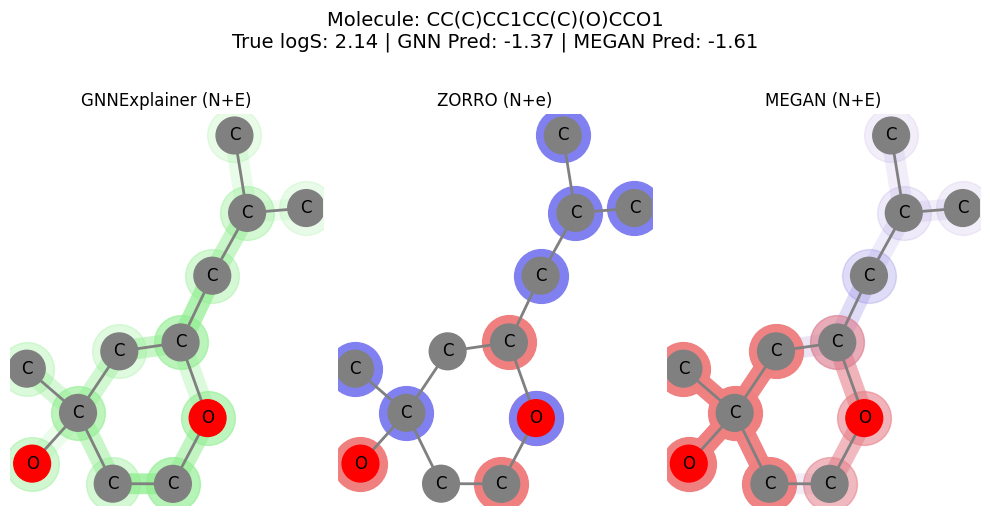

In [37]:
# --- Generate and compare explanations for several example molecules ---

# Pick molecules from the test set that span the solubility range, so the comparison
# covers very insoluble, intermediate and very soluble compounds.
sorted_test = sorted(test_indices, key=lambda i: data_frame.iloc[i]['solubility'])
pick_positions = [0, len(sorted_test) // 3, 2 * len(sorted_test) // 3, len(sorted_test) - 1]
comparison_indices = [sorted_test[p] for p in pick_positions]
comparison_molecules = [data_frame.iloc[i]['smiles'] for i in comparison_indices]

print("Generating explanations for comparison molecules...\n")

for i, smiles in enumerate(comparison_molecules):
    print(f"Processing molecule {i+1}/{len(comparison_molecules)}: {smiles}")

    # Use the true solubility value from the dataset as the reference target
    row = data_frame[data_frame['smiles'] == smiles].iloc[0]
    target = float(row['solubility'])

    try:
        explanations = generate_all_explanations(
            smiles=smiles,
            target=target,
            gnn_model=model.model.copy(),  # Use the native torch module
            gnn_explainer=explainer,
            megan_model=megan_model,
        )

        plot_explanation_comparison(smiles, explanations)

    except Exception as e:
        print(f"  Error processing molecule: {e}")
        continue

### Observations and Discussion

With all three methods shown side by side, we can compare both where they agree and how differently they present an explanation.

**GNNExplainer.** As already discussed further above, GNNExplainer assigns a continuous, unsigned importance value to almost every atom, and in practice the differences between these values tend to be small. A heat-map in which nearly the whole molecule is highlighted with a similar intensity is not very useful for human interpretation: it neither points to a clear substructure nor tells us whether a given region raises or lowers the predicted solubility.

**ZORRO and MEGAN agree on the broad regions.** The two directional methods tend to point to the same chemically sensible regions of the molecule. Terminal oxygen-containing groups are consistently picked up as a *positive*, solubility-supporting influence, while the carbon core is marked as a *negative*, solubility-limiting one. So when it comes to the question of *which* part of the molecule matters, and in *which* direction, ZORRO and MEGAN largely agree with one another.

**But they differ qualitatively.** Where the two differ is in the *character* of the explanation. ZORRO returns a hard, binary selection of atoms, and this selection is often *disconnected* &mdash; it marks several individual atoms spread across the molecule wherever they happen to be sufficient to preserve the prediction, even if these atoms do not form a connected fragment. MEGAN, on the other hand, produces connected highlights but tends to be *diffuse*: the importance of a relevant atom is spread out continuously and often bleeds over onto its direct neighbors, so that the edges of a highlighted region are soft rather than clearly defined.

**Key Takeaways.** No single method is universally "best" &mdash; each gives a different view of the same model. When several methods agree on the same substructures, as ZORRO and MEGAN often do here, this increases our confidence in the explanation. In all cases, however, domain knowledge remains essential for judging whether the highlighted substructures correspond to meaningful structure-property relationships.

<details style="border: 1.5px #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 Why does ZORRO return no atoms for the most insoluble molecule?</summary>

For the first molecule in the comparison &mdash; the most insoluble compound in our test set, a heavily chlorinated polycyclic aromatic &mdash; ZORRO highlights no atoms at all, in either direction. This is not an error; it follows from how ZORRO measures sufficiency for a molecule this far from the training data.

The molecule lies at the edge of the training distribution, so its predicted solubility is very low. ZORRO estimates the RDT-Fidelity by repeatedly replacing the <em>unselected</em> atoms with random "noise" atoms sampled from the training set. For a molecule this atypical, almost any such substitution makes part of it more ordinary, and therefore more soluble, so nearly every perturbation <em>raises</em> the predicted value. The prediction is already near its floor and can only move upward.

The two directions therefore behave differently. For <code>direction='down'</code>, a trial only counts as broken if the prediction <em>drops</em> below the tolerance band; since the substitutions never push the already-low prediction lower, the band is satisfied even by the empty set, and ZORRO has no reason to select any atom. For <code>direction='up'</code>, a trial breaks whenever the prediction <em>rises</em> above the band, which is what almost every substitution does, so no small subset of atoms can hold the prediction down and the fidelity never reaches the threshold $\tau$. In neither direction does a sufficient set emerge. The molecule does have relevant substructures; the perturbation-based definition of sufficiency simply does not apply, this far out in the distribution.

</details>

## **2.6** $\cdot$ 🔬 Discussion and Limitations

The structure-attribution methods presented in this tutorial offer direct insight into which atoms and bonds a graph neural network considers important for its predictions. However, several considerations should guide the interpretation and application of these explanations.

**Explanation Faithfulness.** A central question for any explanation method is whether the highlighted substructures actually reflect the model's decision-making process. For post-hoc methods such as GNNExplainer and ZORRO, explanations are generated by analyzing a model that was not designed with interpretability in mind. These methods make assumptions that may not perfectly align with the model's internal computations &mdash; for instance, perturbation-based approaches assume that masking nodes or edges approximates their removal, but message passing on a partially masked graph behaves differently than on a truly smaller molecular graph. Intrinsic explanation methods like MEGAN address this concern by producing explanations as a direct byproduct of the prediction itself: the same attention weights that generate the explanation also determine how information flows through the network. This architectural coupling is intended to increase the alignment between the explanation and actual model behavior. However, intrinsic methods require committing to a specific model architecture, whereas post-hoc methods can be applied to any pre-trained GNN. The choice between these paradigms often involves a trade-off between explanation faithfulness and flexibility.

**Hyperparameter Sensitivity and Method Agreement.** The explanations produced by structure-attribution methods can depend substantially on hyperparameter choices &mdash; the number of optimization epochs in GNNExplainer, the tolerance and fidelity threshold in ZORRO, or the sparsity factor in MEGAN all influence which substructures are highlighted and how focused the explanations appear. Importantly, different hyperparameter settings can lead to substantially different explanations *from the same method* on the same molecule, not only disagreements between methods. When comparing explanations across methods, as demonstrated in the comparison section above, apparent disagreements may therefore reflect differences in configuration rather than fundamental differences in what the methods reveal. This underscores the importance of actively engaging with the explanation process rather than treating it as a black-box procedure. Practitioners should experiment with hyperparameter settings and verify that explanations behave sensibly on molecules with known structure-property relationships.

**Practical Implications.** Given the potential for disagreement both between and within methods, it is advisable to apply multiple explanation approaches and examine where they converge or diverge. Consistent highlighting of the same substructure across different methods can increase confidence in its relevance, while disagreement may warrant closer investigation. More broadly, explanation methods should be understood as approximative tools rather than authoritative oracles &mdash; they can be as flawed or biased as the models they aim to explain. Treating explanations as one source of evidence among many, rather than definitive answers, helps avoid overconfidence in potentially misleading results. Finally, computational costs should inform method selection. GNNExplainer and ZORRO both require substantial computation for each individual molecule (GNNExplainer optimizes a mask per graph; ZORRO runs a greedy search with many Monte-Carlo perturbations), making them impractical when explanations are needed for large numbers of compounds. In such scenarios, methods that amortize the computational cost through pre-training &mdash; such as MEGAN &mdash; offer more scalable alternatives.

## **References**

**Datasets**

- Sorkun, M. C., Khetan, A., & Er, S. (2019). AqSolDB, a curated reference set of aqueous solubility and 2D descriptors for a diverse set of compounds. *Scientific Data*, 6(1), 143. https://doi.org/10.1038/s41597-019-0151-1

**Methods**

- Ying, Z., Bourgeois, D., You, J., Zitnik, M., & Leskovec, J. (2019). GNNExplainer: Generating explanations for graph neural networks. *Advances in Neural Information Processing Systems*, 32. https://arxiv.org/abs/1903.03894

- Funke, T., Khosla, M., Rathee, M., & Anand, A. (2021). Zorro: Valid, sparse, and stable explanations in graph neural networks. *arXiv preprint* arXiv:2105.08621. https://arxiv.org/abs/2105.08621 | [GitHub (zorrito)](https://github.com/the16thpythonist/zorrito)

- Teufel, J., Torresi, L., Reiser, P., & Friederich, P. (2023). MEGAN: Multi-explanation graph attention network. In *Explainable Artificial Intelligence (xAI 2023)*, Communications in Computer and Information Science, vol. 1903, pp. 338–360. Springer. https://link.springer.com/chapter/10.1007/978-3-031-44067-0_18 | [GitHub](https://github.com/aimat-lab/graph_attention_student)

**Software**

- Landrum, G. et al. (2024). RDKit: Open-source cheminformatics software. https://www.rdkit.org

- Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., ... & Chintala, S. (2019). PyTorch: An imperative style, high-performance deep learning library. *Advances in Neural Information Processing Systems*, 32. https://pytorch.org

- Falcon, W. et al. (2019). PyTorch Lightning. https://lightning.ai/docs/pytorch/stable/

- Fey, M., & Lenssen, J. E. (2019). Fast graph representation learning with PyTorch Geometric. In *ICLR Workshop on Representation Learning on Graphs and Manifolds*. https://pytorch-geometric.readthedocs.io

- Hagberg, A. A., Schult, D. A., & Swart, P. J. (2008). Exploring network structure, dynamics, and function using NetworkX. In *Proceedings of the 7th Python in Science Conference*, pp. 11–15. https://networkx.org